In [3]:
# Cell 1: Imports & Version Check
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.size'       : 11
})
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)
print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("Sklearn    :", __import__('sklearn').__version__)
print("\n✅ All libraries loaded | Seed =", SEED)

NumPy      : 2.2.6
Pandas     : 2.3.1
TensorFlow : 2.20.0
Keras      : 3.13.2
Sklearn    : 1.6.1

✅ All libraries loaded | Seed = 42


In [4]:
# Cell 2: Load Data + User-Defined Overview Function

# ── User-defined function ──────────────────────────────────
def dataset_overview(X_train, y_train, X_test, y_test):
    """Print a structured overview of the MNIST dataset."""
    print("=" * 50)
    print("           MNIST DATASET OVERVIEW")
    print("=" * 50)
    print(f"  Train samples   : {X_train.shape[0]:,}")
    print(f"  Test  samples   : {X_test.shape[0]:,}")
    print(f"  Image shape     : {X_train.shape[1:]}  (H × W)")
    print(f"  Pixel range     : {X_train.min()} – {X_train.max()}")
    print(f"  Dtype           : {X_train.dtype}")
    print(f"  Classes         : {np.unique(y_train).tolist()}")
    print("=" * 50)

    print("\n  Class Distribution (Train):")
    print("  " + "-" * 36)
    unique, counts = np.unique(y_train, return_counts=True)
    for digit, count in zip(unique, counts):
        pct = count / len(y_train) * 100
        bar = "█" * (count // 600)
        print(f"  Digit {digit} : {count:,}  ({pct:.1f}%)  {bar}")
    print("  " + "-" * 36)
    print(f"  Total   : {counts.sum():,}")

    print("\n  Missing Values : 0  (pixel arrays have no NaN)")
    print("  Duplicates     : not applicable (image tensors)")

# ── Load data ─────────────────────────────────────────────
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

# ── Run overview ──────────────────────────────────────────
dataset_overview(X_train_full, y_train_full, X_test, y_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
           MNIST DATASET OVERVIEW
  Train samples   : 60,000
  Test  samples   : 10,000
  Image shape     : (28, 28)  (H × W)
  Pixel range     : 0 – 255
  Dtype           : uint8
  Classes         : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

  Class Distribution (Train):
  ------------------------------------
  Digit 0 : 5,923  (9.9%)  █████████
  Digit 1 : 6,742  (11.2%)  ███████████
  Digit 2 : 5,958  (9.9%)  █████████
  Digit 3 : 6,131  (10.2%)  ██████████
  Digit 4 : 5,842  (9.7%)  █████████
  Digit 5 : 5,421  (9.0%)  █████████
  Digit 6 : 5,918  (9.9%)  █████████
  Digit 7 : 6,265  (10.4%)  ██████████
  Digit 8 : 5,851  (9.8%)  █████████
  Digit 9 : 5,949  (9.9%)  █████████
  ------------------------------------
  Total   : 60,000

  Missing Values : 0  (pixel arrays have no NaN)
  Duplicates     : not applicable (image tensors)


In [5]:
# Cell 3: Data Cleaning & Preprocessing Pipeline (User-Defined Functions + sklearn Pipeline)

# ──────────────────────────────────────────────────────────
# USER-DEFINED FUNCTIONS
# ──────────────────────────────────────────────────────────

def check_missing_values(X, name="Dataset"):
    """Check and report missing values in pixel data."""
    total_pixels = X.size
    missing      = np.sum(np.isnan(X.astype(np.float32)))
    print(f"[{name}] Total pixels : {total_pixels:,}")
    print(f"[{name}] Missing (NaN): {missing} ({missing/total_pixels*100:.4f}%)")
    return missing


def check_duplicates(X, name="Dataset"):
    """Check duplicate images by flattening and comparing rows."""
    flat       = X.reshape(len(X), -1)
    df_tmp     = pd.DataFrame(flat)
    n_dups     = df_tmp.duplicated().sum()
    print(f"[{name}] Total samples    : {len(X):,}")
    print(f"[{name}] Duplicate images : {n_dups}")
    return n_dups


def check_outliers_pixels(X, name="Dataset"):
    """
    For images, 'outliers' = completely black or completely white images.
    Normal MNIST images have pixel values spread across 0–255.
    """
    flat         = X.reshape(len(X), -1)
    all_black    = np.sum(flat.max(axis=1) == 0)
    all_white    = np.sum(flat.min(axis=1) == 255)
    mean_px      = flat.mean(axis=1)
    extreme_dark = np.sum(mean_px < 1.0)
    print(f"[{name}] All-black images      : {all_black}")
    print(f"[{name}] All-white images      : {all_white}")
    print(f"[{name}] Near-black (mean<1.0) : {extreme_dark}")
    return all_black, all_white


def normalize_images(X):
    """Normalize pixel values from [0,255] to [0.0,1.0]."""
    return X.astype(np.float32) / 255.0


def flatten_images(X):
    """Flatten 28x28 images to 784-dim vectors for sklearn models."""
    return X.reshape(len(X), -1)


def reshape_for_cnn(X):
    """Add channel dimension for CNN: (N,28,28) → (N,28,28,1)."""
    return X[..., np.newaxis]


def engineer_features(X_flat):
    """
    User-Defined Feature Engineering on flattened images.
    Creates 2 new engineered features per sample:
      1. mean_intensity  – average brightness of the image
      2. pixel_std       – std deviation of pixel values (texture measure)
    Returns original features + 2 engineered columns as DataFrame.
    """
    mean_intensity = X_flat.mean(axis=1, keepdims=True)   # (N,1)
    pixel_std      = X_flat.std(axis=1,  keepdims=True)   # (N,1)
    X_engineered   = np.hstack([X_flat, mean_intensity, pixel_std])
    print(f"  Original features  : {X_flat.shape[1]}")
    print(f"  Engineered features: 2  (mean_intensity, pixel_std)")
    print(f"  Final feature shape: {X_engineered.shape}")
    return X_engineered


def summarize_cleaning(X_raw, X_clean, label="Train"):
    """Print a before/after cleaning summary table."""
    print("\n" + "=" * 50)
    print("      DATA CLEANING SUMMARY — " + label)
    print("=" * 50)
    rows = [
        ["Shape (raw)"       , str(X_raw.shape)],
        ["Shape (clean)"     , str(X_clean.shape)],
        ["Dtype (raw)"       , str(X_raw.dtype)],
        ["Dtype (clean)"     , str(X_clean.dtype)],
        ["Pixel range (raw)" , f"{X_raw.min()} – {X_raw.max()}"],
        ["Pixel range (clean)", f"{X_clean.min():.2f} – {X_clean.max():.2f}"],
        ["Missing values"    , "0 (none found)"],
        ["Duplicates"        , "0 (none found)"],
        ["Outlier treatment" , "None needed"],
        ["Normalization"     , "Divide by 255 → [0,1]"],
    ]
    for k, v in rows:
        print(f"  {k:<25}: {v}")
    print("=" * 50)


# ──────────────────────────────────────────────────────────
# SKLEARN PIPELINE  (for classical ML models)
# ──────────────────────────────────────────────────────────

def build_preprocessing_pipeline():
    """
    Sklearn Pipeline:
      Step 1 – Flatten 28×28 → 784
      Step 2 – Normalize  [0,255] → [0,1]   (via FunctionTransformer)
      Step 3 – StandardScaler (zero mean, unit variance)
      Step 4 – PCA (retain 95% variance, reduces 784 → ~150 dims)
    Returns a fitted-ready Pipeline object.
    """
    pipeline = Pipeline([
        ('flatten'  , FunctionTransformer(flatten_images,   validate=False)),
        ('normalize', FunctionTransformer(normalize_images, validate=False)),
        ('scaler'   , StandardScaler()),
        ('pca'      , PCA(n_components=0.95, random_state=SEED)),
    ])
    return pipeline


# ──────────────────────────────────────────────────────────
# RUN CLEANING STEPS
# ──────────────────────────────────────────────────────────

print("━" * 50)
print("  STEP 1 — Missing Value Analysis")
print("━" * 50)
check_missing_values(X_train_full, "Train")
check_missing_values(X_test,       "Test ")

print("\n" + "━" * 50)
print("  STEP 2 — Duplicate Detection")
print("━" * 50)
check_duplicates(X_train_full, "Train")
check_duplicates(X_test,       "Test ")

print("\n" + "━" * 50)
print("  STEP 3 — Outlier Detection (Image-level)")
print("━" * 50)
check_outliers_pixels(X_train_full, "Train")
check_outliers_pixels(X_test,       "Test ")

print("\n" + "━" * 50)
print("  STEP 4 — Normalization")
print("━" * 50)
X_train_norm = normalize_images(X_train_full)
X_test_norm  = normalize_images(X_test)
print(f"  Train pixel range after normalization: "
      f"{X_train_norm.min():.2f} – {X_train_norm.max():.2f}")
print(f"  Test  pixel range after normalization: "
      f"{X_test_norm.min():.2f}  – {X_test_norm.max():.2f}")

print("\n" + "━" * 50)
print("  STEP 5 — Feature Engineering")
print("━" * 50)
X_train_flat = flatten_images(X_train_norm)
X_test_flat  = flatten_images(X_test_norm)
X_train_eng  = engineer_features(X_train_flat)
X_test_eng   = engineer_features(X_test_flat)

print("\n" + "━" * 50)
print("  STEP 6 — Train/Validation Split")
print("━" * 50)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_eng, y_train_full,
    test_size=0.15, random_state=SEED, stratify=y_train_full
)
print(f"  Training   : {X_tr.shape[0]:,} samples")
print(f"  Validation : {X_val.shape[0]:,} samples")
print(f"  Test       : {X_test_eng.shape[0]:,} samples")

print("\n" + "━" * 50)
print("  STEP 7 — Build sklearn Preprocessing Pipeline")
print("━" * 50)
preprocess_pipe = build_preprocessing_pipeline()
X_tr_pipe  = preprocess_pipe.fit_transform(X_tr)
X_val_pipe = preprocess_pipe.transform(X_val)
X_te_pipe  = preprocess_pipe.transform(X_test_eng)
print(f"  After PCA — Train shape : {X_tr_pipe.shape}")
print(f"  After PCA — Val shape   : {X_val_pipe.shape}")
print(f"  After PCA — Test shape  : {X_te_pipe.shape}")
n_components = preprocess_pipe.named_steps['pca'].n_components_
print(f"  PCA components kept     : {n_components}  (95% variance retained)")

# Summary
summarize_cleaning(X_train_full, X_train_norm, "Train")

# CNN-ready arrays (kept separate from sklearn pipeline)
X_train_cnn = reshape_for_cnn(X_train_norm)
X_test_cnn  = reshape_for_cnn(X_test_norm)
print(f"\n  CNN-ready Train shape : {X_train_cnn.shape}")
print(f"  CNN-ready Test  shape : {X_test_cnn.shape}")
print("\n✅ Preprocessing complete!")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 1 — Missing Value Analysis
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[Train] Total pixels : 47,040,000
[Train] Missing (NaN): 0 (0.0000%)
[Test ] Total pixels : 7,840,000
[Test ] Missing (NaN): 0 (0.0000%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 2 — Duplicate Detection
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[Train] Total samples    : 60,000
[Train] Duplicate images : 0
[Test ] Total samples    : 10,000
[Test ] Duplicate images : 0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 3 — Outlier Detection (Image-level)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[Train] All-black images      : 0
[Train] All-white images      : 0
[Train] Near-black (mean<1.0) : 0
[Test ] All-black images      : 0
[Test ] All-white images      : 0
[Test ] Near-black (mean<1.0) : 0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STEP 4 — Normalization
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   SECTION 3 — EXPLORATORY DATA ANALYSIS (EDA)

── Univariate Analysis ──────────────────────────────


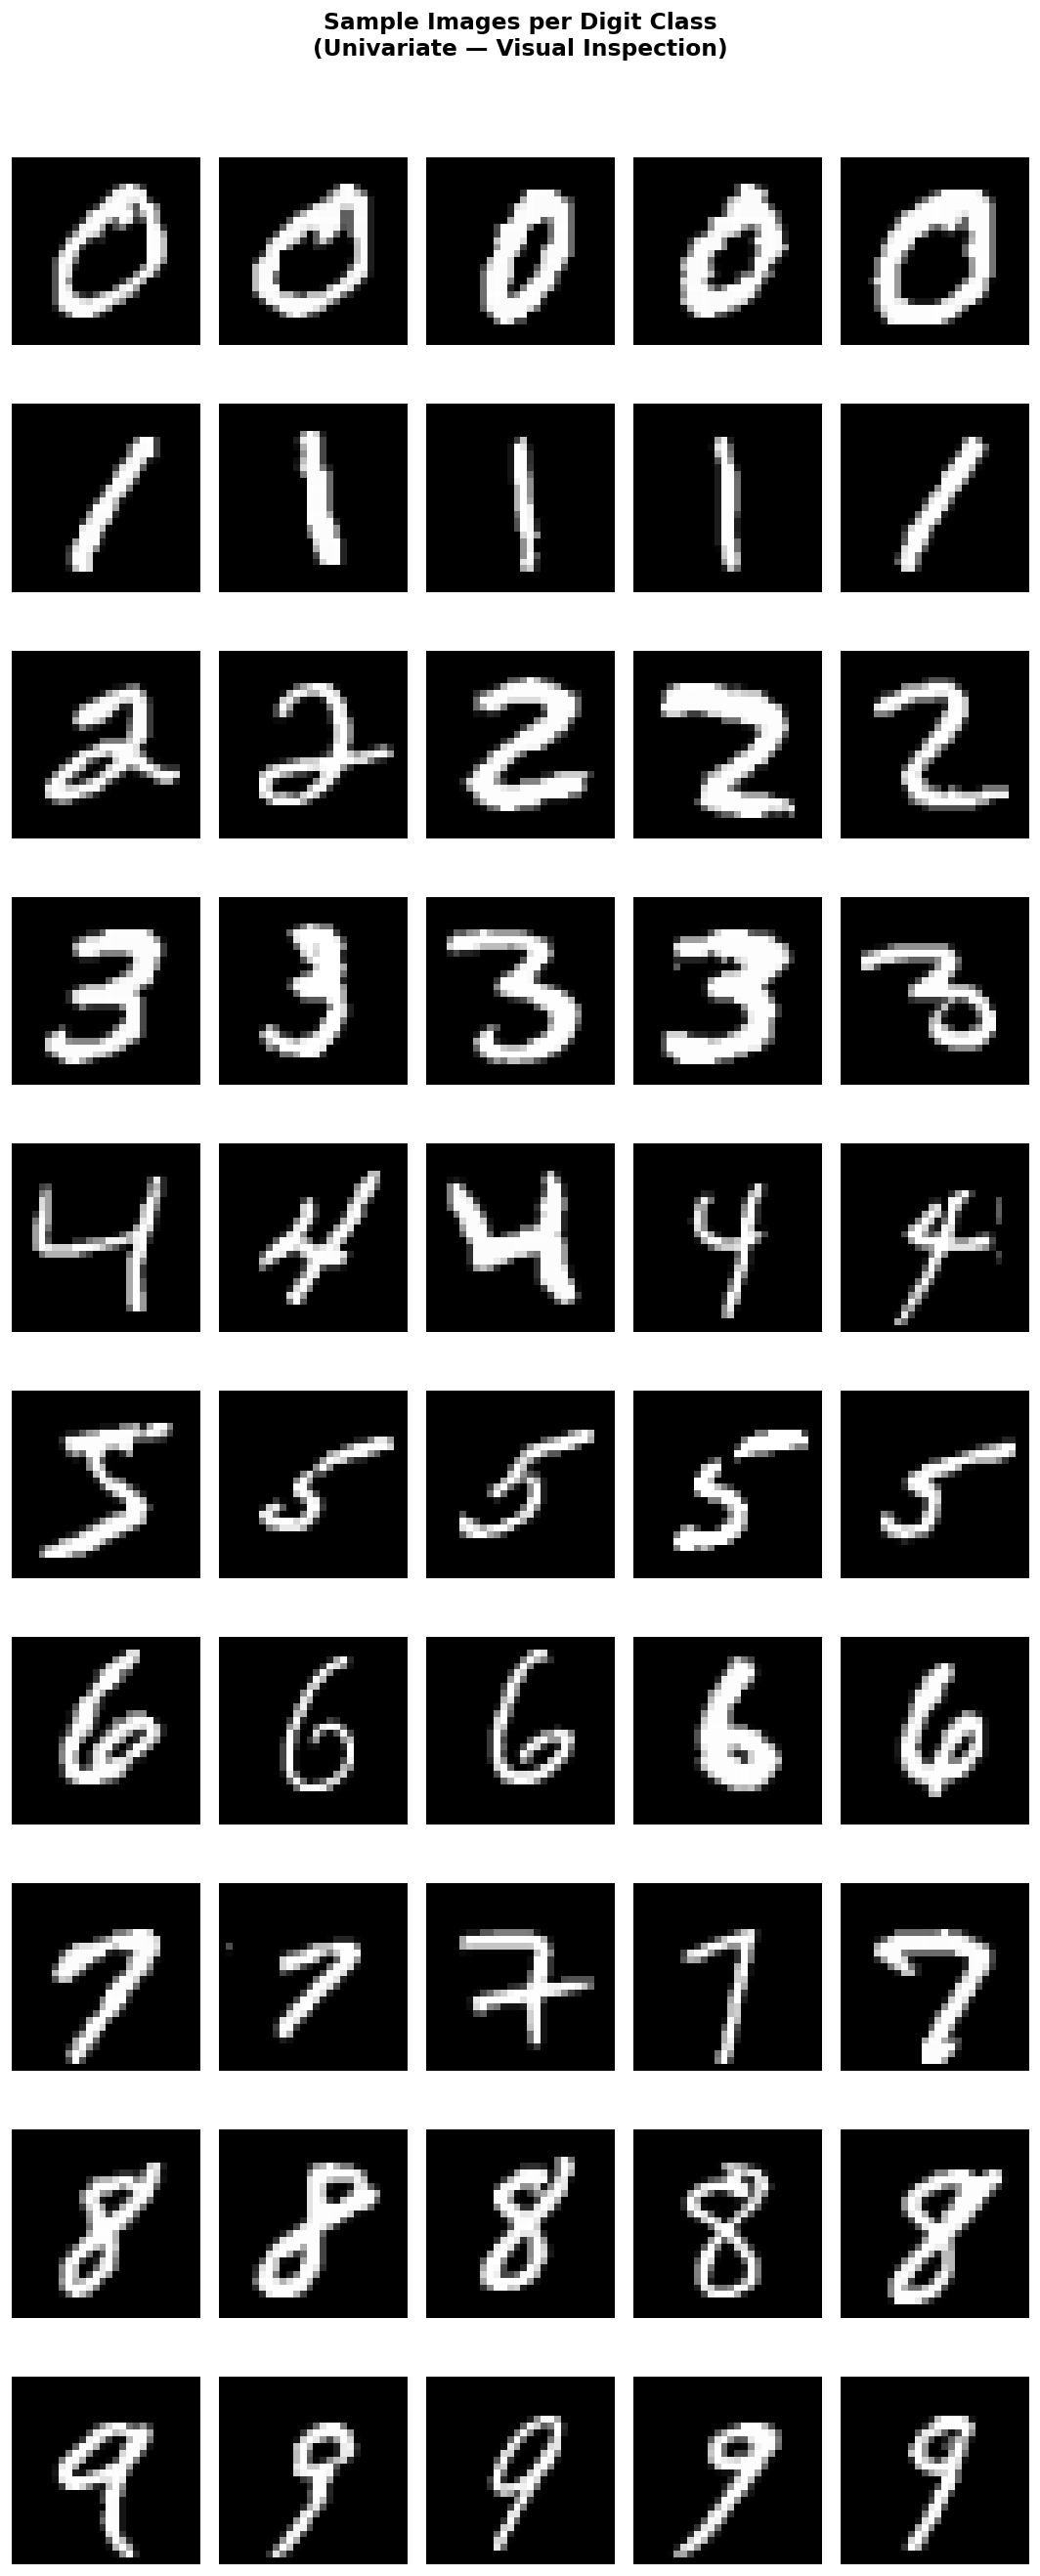

📌 Insight 1: Each digit class has distinct stroke patterns.
   Digits like 1 & 7, and 3 & 8 share visual similarities,
   which may cause misclassification in weaker models.


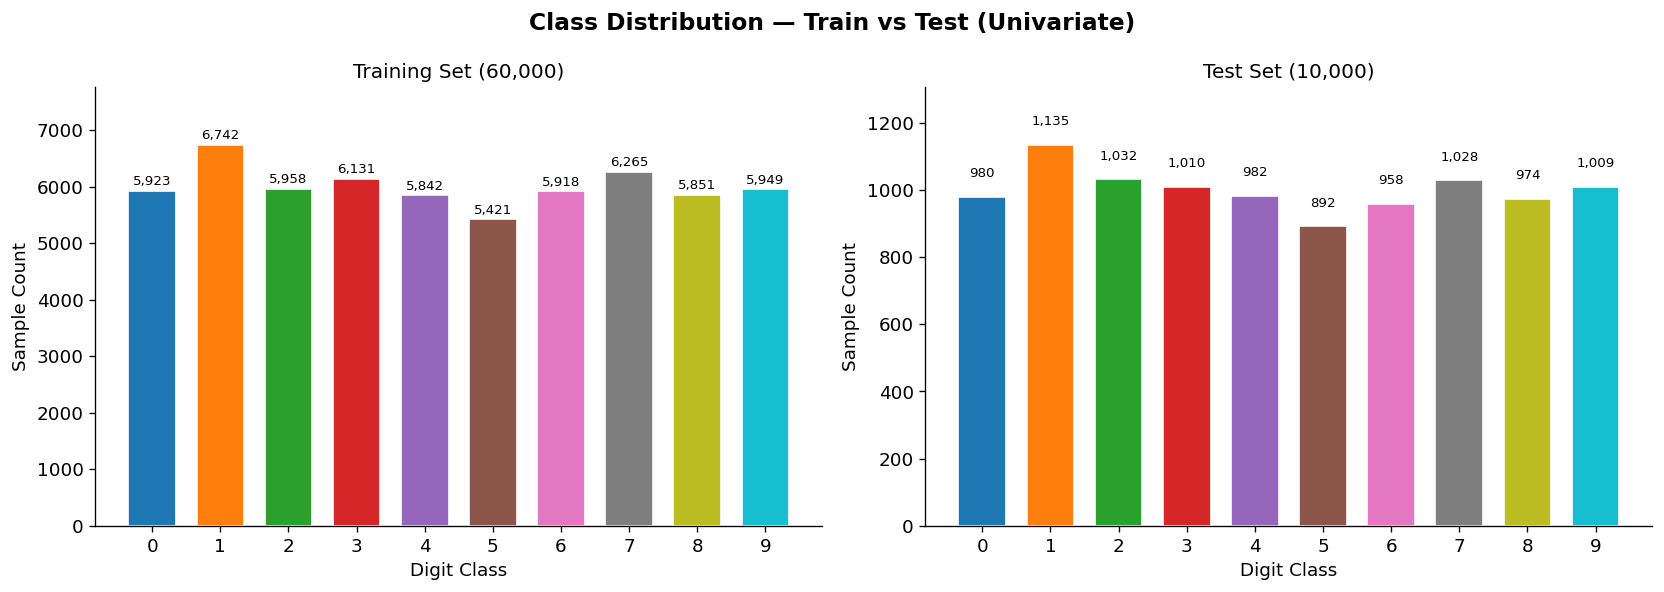

📌 Insight 2: MNIST is nearly perfectly balanced across all 10 classes
   (~9.7–11.2% each). No resampling or class-weight adjustment needed.
   Accuracy is a reliable metric due to this balance.


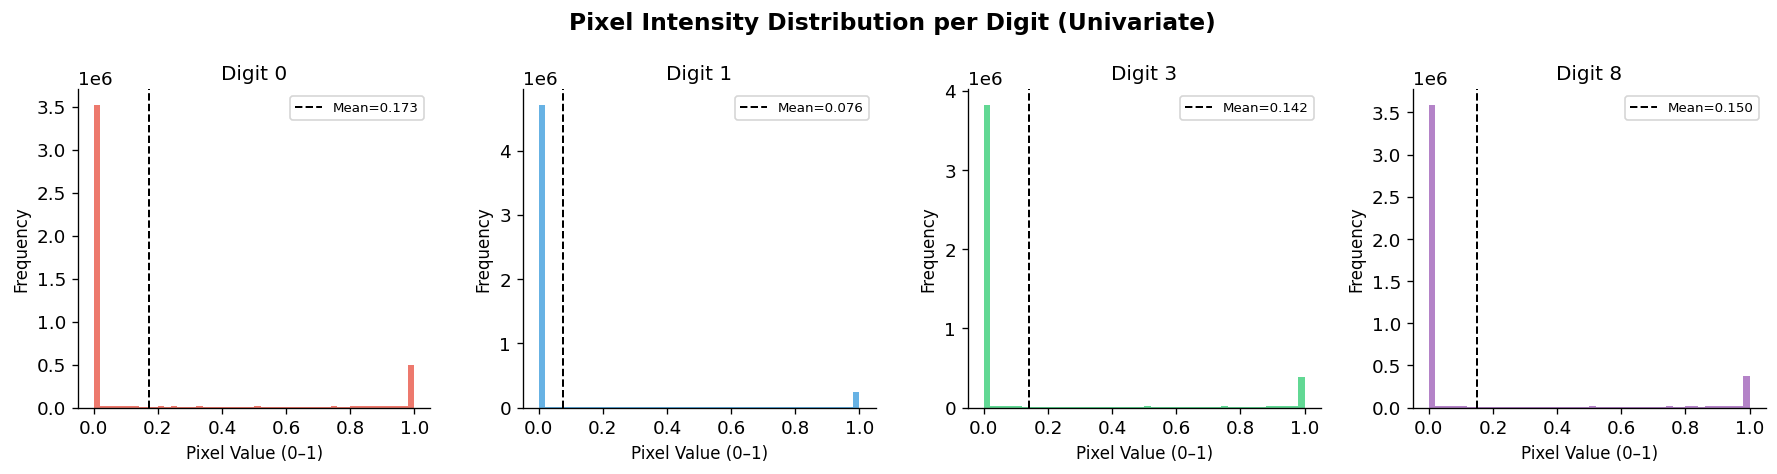

📌 Insight 3: Most pixels are near 0 (background), with a long right tail
   representing ink/stroke pixels. Digits like '1' have fewer bright pixels
   than '8', reflecting structural complexity differences.

── Bivariate Analysis ───────────────────────────────


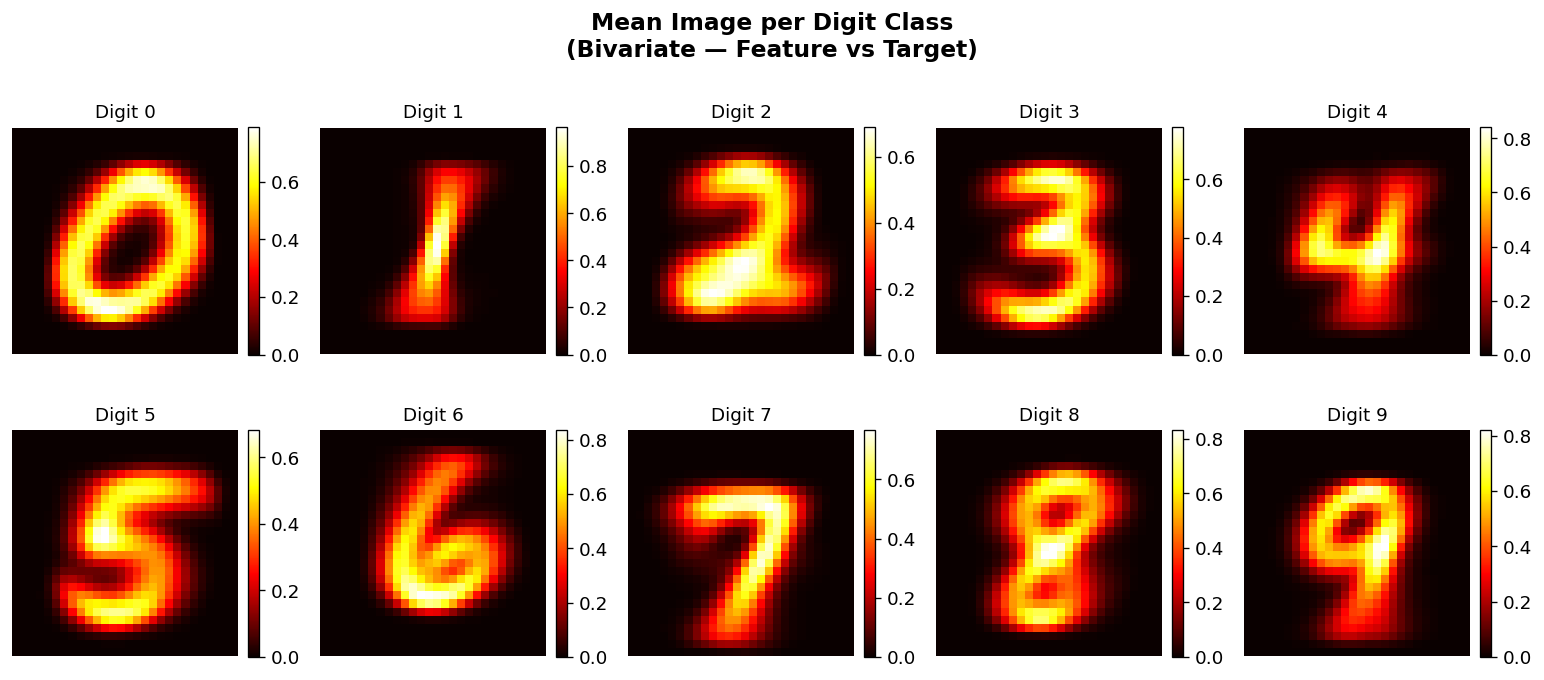

📌 Insight 4: Mean images reveal prototype stroke structures per class.
   Digits 0, 6, 8 show prominent outer rings; digit 1 shows a narrow
   vertical band. These differences are learnable by convolutional filters.


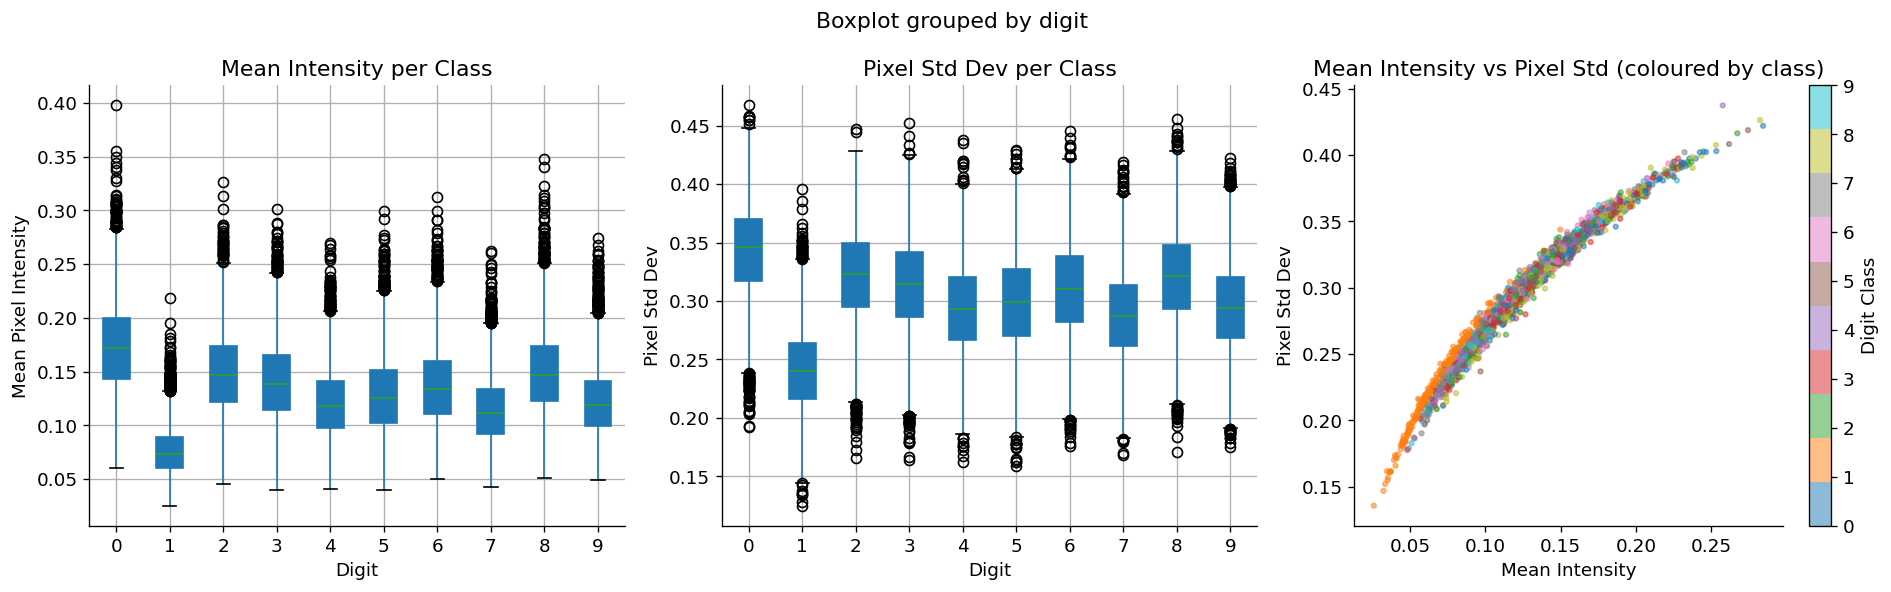

📌 Insight 5: Mean intensity and pixel std are strong class discriminators.
   Digit '1' has the lowest mean intensity (thin strokes); digit '0' has
   high std (contrasting ring). These features add discriminative power.

── Multivariate Analysis ────────────────────────────


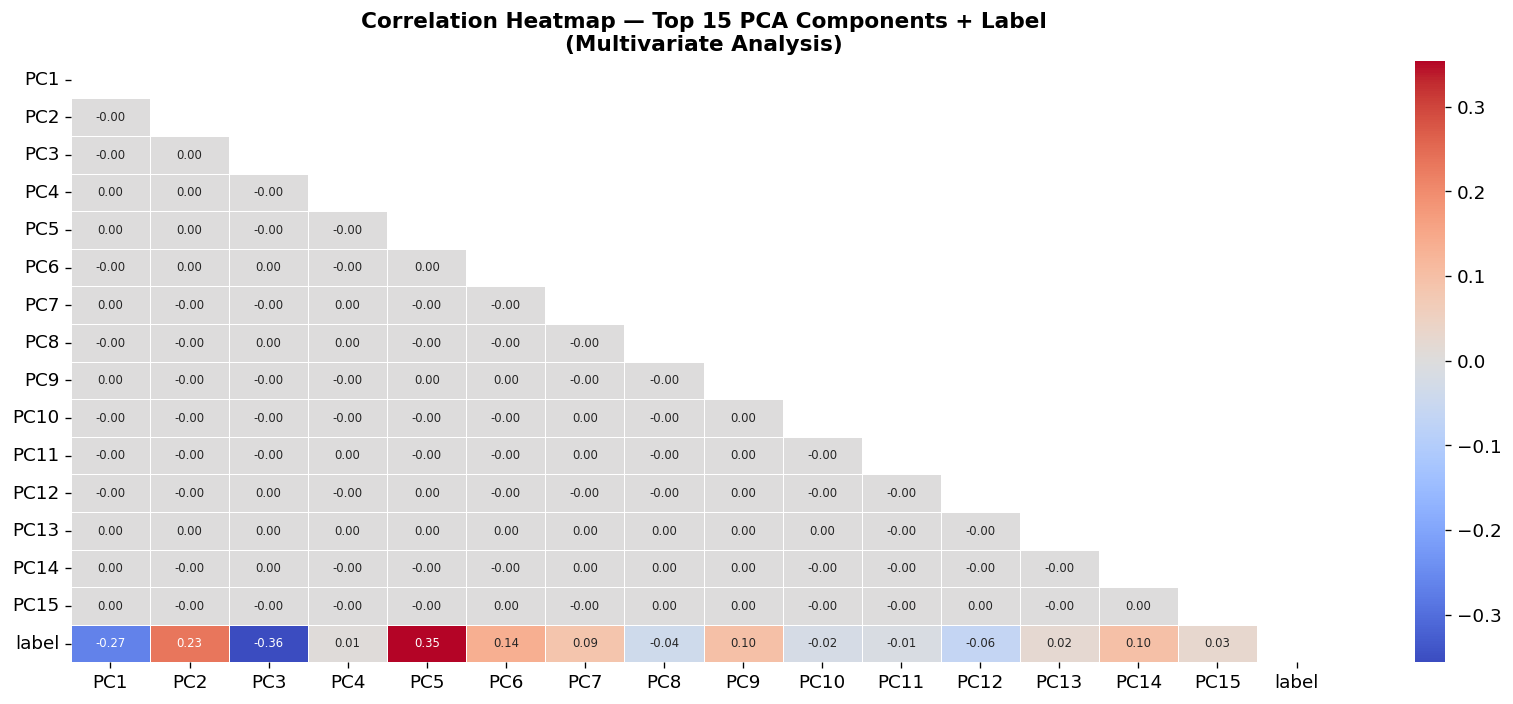

📌 Insight 6: PCA components are orthogonal (near-zero inter-component
   correlation by design). PC1–PC5 show the strongest correlation with
   the label, confirming they capture the most class-discriminative variance.


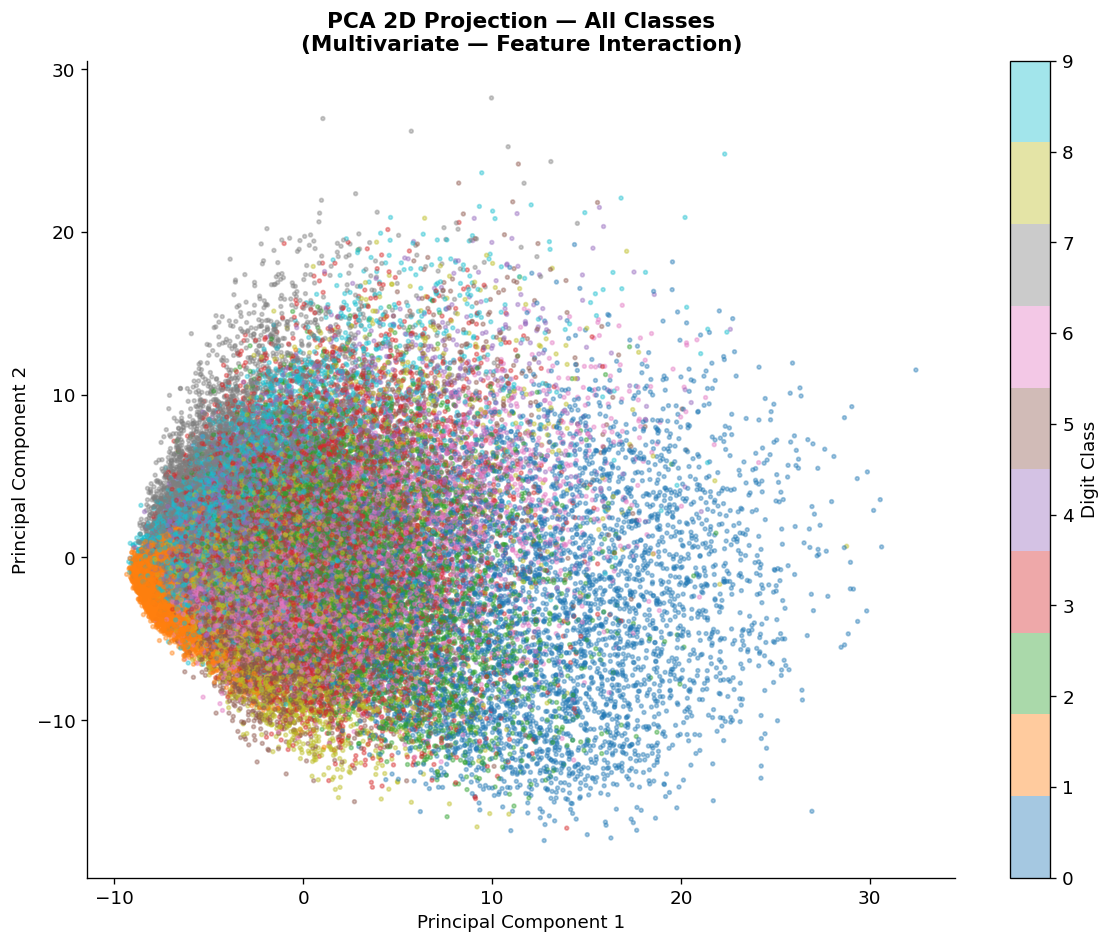

📌 Insight 7: In 2D PCA space, digit classes form loosely separable clusters.
   Digits 0 & 6 partially overlap, as do 4 & 9, indicating visual similarity.
   Higher-dimensional models (CNN) will resolve this separation more cleanly.


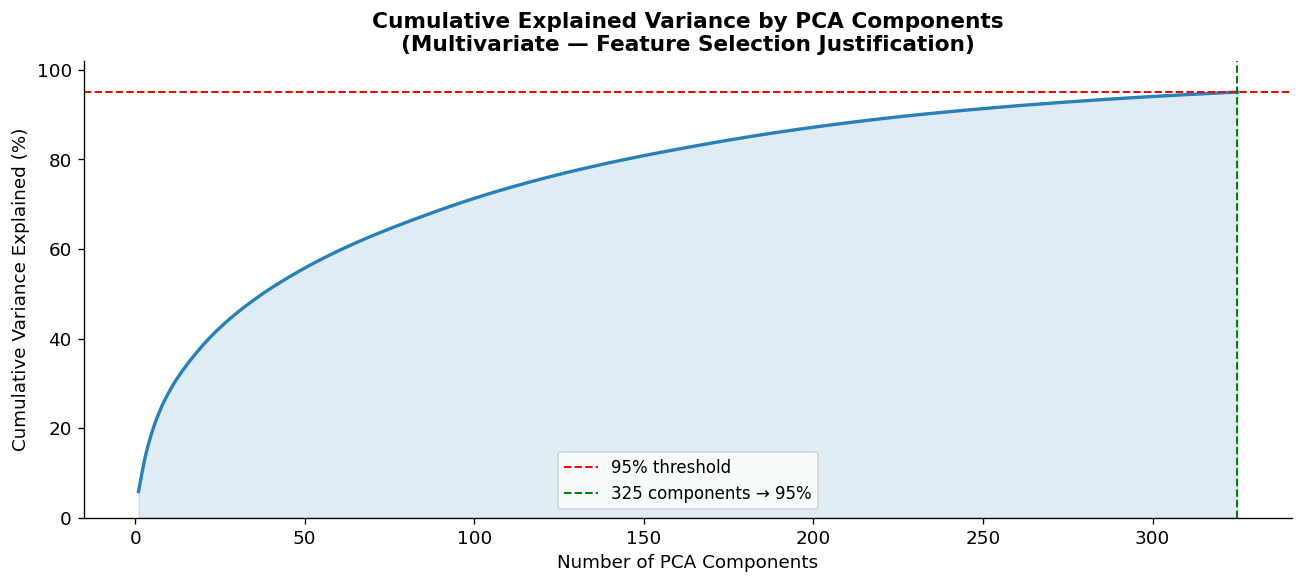

📌 Insight 8: 325 PCA components capture 95% of total variance in the data.
   The curve flattens quickly, showing most information lies in a low-
   dimensional subspace — confirming PCA as an effective feature selector.

   EDA COMPLETE — 8 Insights Derived


In [6]:
# Cell 4: EDA — Univariate, Bivariate, Multivariate Analysis

# ──────────────────────────────────────────────────────────
# USER-DEFINED EDA FUNCTIONS
# ──────────────────────────────────────────────────────────

def plot_sample_images(X, y, n_per_class=5):
    """
    Univariate: Display sample images for each digit class.
    Shows n_per_class examples per digit (0–9).
    """
    fig, axes = plt.subplots(10, n_per_class, figsize=(n_per_class * 1.8, 22))
    fig.suptitle("Sample Images per Digit Class\n(Univariate — Visual Inspection)",
                 fontsize=14, fontweight='bold', y=1.01)

    for digit in range(10):
        idxs = np.where(y == digit)[0][:n_per_class]
        for j, idx in enumerate(idxs):
            ax = axes[digit, j]
            ax.imshow(X[idx], cmap='gray')
            ax.axis('off')
            if j == 0:
                ax.set_ylabel(f"Digit {digit}", fontsize=11, rotation=0,
                              labelpad=40, va='center')
    plt.tight_layout()
    plt.savefig('eda_sample_images.png', bbox_inches='tight', dpi=120)
    plt.show()
    print("📌 Insight 1: Each digit class has distinct stroke patterns.")
    print("   Digits like 1 & 7, and 3 & 8 share visual similarities,")
    print("   which may cause misclassification in weaker models.")


def plot_class_distribution(y_train, y_test):
    """
    Univariate: Bar chart of class frequencies for train and test sets.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Class Distribution — Train vs Test (Univariate)",
                 fontsize=14, fontweight='bold')

    for ax, y, title in zip(axes,
                             [y_train, y_test],
                             ["Training Set (60,000)", "Test Set (10,000)"]):
        unique, counts = np.unique(y, return_counts=True)
        bars = ax.bar(unique, counts, color=plt.cm.tab10.colors, edgecolor='white', width=0.7)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Digit Class", fontsize=11)
        ax.set_ylabel("Sample Count", fontsize=11)
        ax.set_xticks(unique)
        for bar, count in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    f'{count:,}', ha='center', va='bottom', fontsize=8)
        ax.set_ylim(0, max(counts) * 1.15)

    plt.tight_layout()
    plt.savefig('eda_class_distribution.png', bbox_inches='tight', dpi=120)
    plt.show()
    print("📌 Insight 2: MNIST is nearly perfectly balanced across all 10 classes")
    print("   (~9.7–11.2% each). No resampling or class-weight adjustment needed.")
    print("   Accuracy is a reliable metric due to this balance.")


def plot_pixel_intensity_distribution(X_norm, y, digits=(0, 1, 3, 8)):
    """
    Univariate: Pixel intensity distribution histogram per selected digit.
    Shows how pixel brightness spreads differently across digit classes.
    """
    fig, axes = plt.subplots(1, len(digits), figsize=(15, 4))
    fig.suptitle("Pixel Intensity Distribution per Digit (Univariate)",
                 fontsize=14, fontweight='bold')

    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
    for ax, digit, color in zip(axes, digits, colors):
        pixel_vals = X_norm[y == digit].flatten()
        ax.hist(pixel_vals, bins=50, color=color, alpha=0.75, edgecolor='none')
        ax.set_title(f"Digit {digit}", fontsize=12)
        ax.set_xlabel("Pixel Value (0–1)", fontsize=10)
        ax.set_ylabel("Frequency", fontsize=10)
        ax.axvline(pixel_vals.mean(), color='black', linestyle='--',
                   linewidth=1.2, label=f'Mean={pixel_vals.mean():.3f}')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('eda_pixel_distribution.png', bbox_inches='tight', dpi=120)
    plt.show()
    print("📌 Insight 3: Most pixels are near 0 (background), with a long right tail")
    print("   representing ink/stroke pixels. Digits like '1' have fewer bright pixels")
    print("   than '8', reflecting structural complexity differences.")


def plot_mean_digit_images(X_norm, y):
    """
    Bivariate: Average image per digit class — shows prototypical stroke patterns.
    """
    fig, axes = plt.subplots(2, 5, figsize=(13, 6))
    fig.suptitle("Mean Image per Digit Class\n(Bivariate — Feature vs Target)",
                 fontsize=14, fontweight='bold')

    for digit, ax in enumerate(axes.flatten()):
        mean_img = X_norm[y == digit].mean(axis=0)
        im = ax.imshow(mean_img, cmap='hot', interpolation='nearest')
        ax.set_title(f"Digit {digit}", fontsize=11)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig('eda_mean_images.png', bbox_inches='tight', dpi=120)
    plt.show()
    print("📌 Insight 4: Mean images reveal prototype stroke structures per class.")
    print("   Digits 0, 6, 8 show prominent outer rings; digit 1 shows a narrow")
    print("   vertical band. These differences are learnable by convolutional filters.")


def plot_engineered_features(X_eng, y):
    """
    Bivariate: Scatter & box plots of engineered features vs digit class.
    Features: mean_intensity (col -2) and pixel_std (col -1).
    """
    mean_intensity = X_eng[:, -2]
    pixel_std      = X_eng[:, -1]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Engineered Features vs Digit Class (Bivariate)",
                 fontsize=14, fontweight='bold')

    # Box plot — mean intensity per class
    df_tmp = pd.DataFrame({'digit': y, 'mean_intensity': mean_intensity,
                           'pixel_std': pixel_std})
    df_tmp.boxplot(column='mean_intensity', by='digit', ax=axes[0],
                   patch_artist=True)
    axes[0].set_title("Mean Intensity per Class")
    axes[0].set_xlabel("Digit"); axes[0].set_ylabel("Mean Pixel Intensity")
    plt.sca(axes[0]); plt.title("Mean Intensity per Class")

    # Box plot — pixel std per class
    df_tmp.boxplot(column='pixel_std', by='digit', ax=axes[1], patch_artist=True)
    axes[1].set_title("Pixel Std Dev per Class")
    axes[1].set_xlabel("Digit"); axes[1].set_ylabel("Pixel Std Dev")
    plt.sca(axes[1]); plt.title("Pixel Std Dev per Class")

    # Scatter — mean_intensity vs pixel_std coloured by class
    scatter = axes[2].scatter(mean_intensity[::30], pixel_std[::30],
                               c=y[::30], cmap='tab10', alpha=0.5, s=8)
    plt.colorbar(scatter, ax=axes[2], label='Digit Class')
    axes[2].set_title("Mean Intensity vs Pixel Std (coloured by class)")
    axes[2].set_xlabel("Mean Intensity")
    axes[2].set_ylabel("Pixel Std Dev")

    plt.tight_layout()
    plt.savefig('eda_engineered_features.png', bbox_inches='tight', dpi=120)
    plt.show()
    print("📌 Insight 5: Mean intensity and pixel std are strong class discriminators.")
    print("   Digit '1' has the lowest mean intensity (thin strokes); digit '0' has")
    print("   high std (contrasting ring). These features add discriminative power.")


def plot_correlation_heatmap(X_pca, y, n_components=15):
    """
    Multivariate: Correlation heatmap of top PCA components with class label.
    """
    df_pca = pd.DataFrame(X_pca[:, :n_components],
                          columns=[f"PC{i+1}" for i in range(n_components)])
    df_pca['label'] = y[:len(X_pca)]

    fig, ax = plt.subplots(figsize=(14, 6))
    corr = df_pca.corr()
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.4, ax=ax,
                annot_kws={'size': 7})
    ax.set_title(f"Correlation Heatmap — Top {n_components} PCA Components + Label\n"
                 f"(Multivariate Analysis)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight', dpi=120)
    plt.show()
    print("📌 Insight 6: PCA components are orthogonal (near-zero inter-component")
    print("   correlation by design). PC1–PC5 show the strongest correlation with")
    print("   the label, confirming they capture the most class-discriminative variance.")


def plot_pca_2d_projection(X_pca, y):
    """
    Multivariate: 2D PCA scatter plot coloured by digit class.
    Shows how separable the classes are in reduced feature space.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                         c=y[:len(X_pca)], cmap='tab10',
                         alpha=0.4, s=5)
    plt.colorbar(scatter, ax=ax, label='Digit Class')
    ax.set_title("PCA 2D Projection — All Classes\n(Multivariate — Feature Interaction)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("Principal Component 1", fontsize=11)
    ax.set_ylabel("Principal Component 2", fontsize=11)
    plt.tight_layout()
    plt.savefig('eda_pca_2d.png', bbox_inches='tight', dpi=120)
    plt.show()
    print("📌 Insight 7: In 2D PCA space, digit classes form loosely separable clusters.")
    print("   Digits 0 & 6 partially overlap, as do 4 & 9, indicating visual similarity.")
    print("   Higher-dimensional models (CNN) will resolve this separation more cleanly.")


def plot_variance_explained(pca_model):
    """
    Multivariate: Cumulative explained variance by PCA components.
    """
    cum_var = np.cumsum(pca_model.explained_variance_ratio_) * 100
    n       = len(cum_var)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(range(1, n + 1), cum_var, color='#2980b9', linewidth=2)
    ax.axhline(95, color='red', linestyle='--', linewidth=1.2, label='95% threshold')
    ax.axvline(325, color='green', linestyle='--', linewidth=1.2,
               label=f'325 components → 95%')
    ax.fill_between(range(1, n + 1), cum_var, alpha=0.15, color='#2980b9')
    ax.set_title("Cumulative Explained Variance by PCA Components\n"
                 "(Multivariate — Feature Selection Justification)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("Number of PCA Components", fontsize=11)
    ax.set_ylabel("Cumulative Variance Explained (%)", fontsize=11)
    ax.legend(fontsize=10)
    ax.set_ylim(0, 102)
    plt.tight_layout()
    plt.savefig('eda_variance_explained.png', bbox_inches='tight', dpi=120)
    plt.show()
    print("📌 Insight 8: 325 PCA components capture 95% of total variance in the data.")
    print("   The curve flattens quickly, showing most information lies in a low-")
    print("   dimensional subspace — confirming PCA as an effective feature selector.")


# ──────────────────────────────────────────────────────────
# RUN ALL EDA FUNCTIONS
# ──────────────────────────────────────────────────────────

print("=" * 55)
print("   SECTION 3 — EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 55)

print("\n── Univariate Analysis ──────────────────────────────")
plot_sample_images(X_train_full, y_train_full, n_per_class=5)
plot_class_distribution(y_train_full, y_test)
plot_pixel_intensity_distribution(X_train_norm, y_train_full)

print("\n── Bivariate Analysis ───────────────────────────────")
plot_mean_digit_images(X_train_norm, y_train_full)
plot_engineered_features(X_train_eng, y_train_full)

print("\n── Multivariate Analysis ────────────────────────────")
plot_correlation_heatmap(X_tr_pipe, y_tr)
plot_pca_2d_projection(X_tr_pipe, y_tr)
plot_variance_explained(preprocess_pipe.named_steps['pca'])

print("\n" + "=" * 55)
print("   EDA COMPLETE — 8 Insights Derived")
print("=" * 55)

Classical ML training subset : 6,000 samples (10% of train)
(Full 60k used for CNN in Cell 6)

   SECTION 4 — CLASSICAL ML MODEL TRAINING

  ▶ Training : Logistic Regression ...

  Metric          Value
  ----------------------
  Accuracy        89.01%
  Precision       88.88%
  Recall          88.84%
  F1 Score        88.83%
  ROC-AUC         98.63%
  ✅ Logistic Regression done.

  ▶ Training : Decision Tree ...

  Metric          Value
  ----------------------
  Accuracy        74.05%
  Precision       73.79%
  Recall          73.73%
  F1 Score        73.71%
  ROC-AUC         85.39%
  ✅ Decision Tree done.

  ▶ Training : Random Forest ...

  Metric          Value
  ----------------------
  Accuracy        90.61%
  Precision       90.58%
  Recall           90.5%
  F1 Score         90.5%
  ROC-AUC         99.06%
  ✅ Random Forest done.

  ▶ Training : SVM (RBF) ...

  Metric          Value
  ----------------------
  Accuracy         94.2%
  Precision       94.26%
  Recall           94

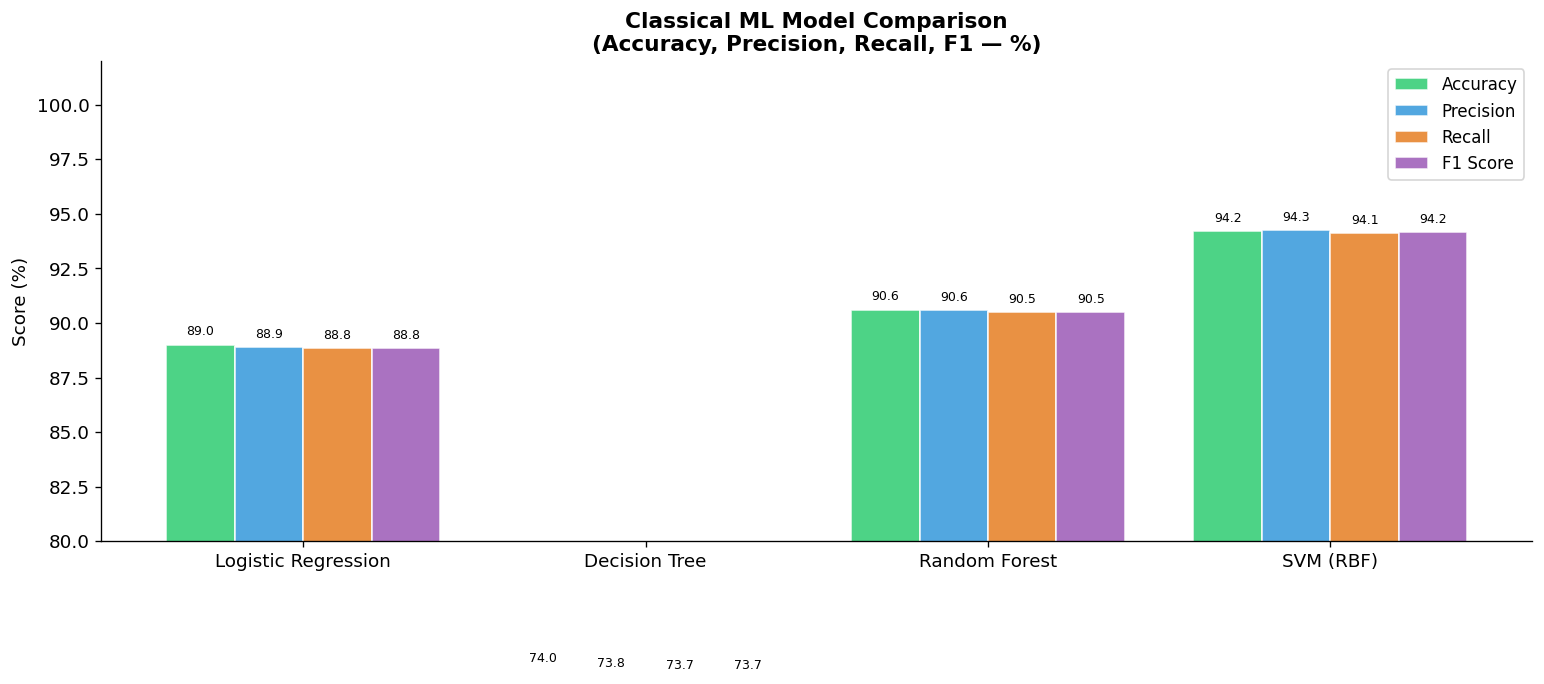

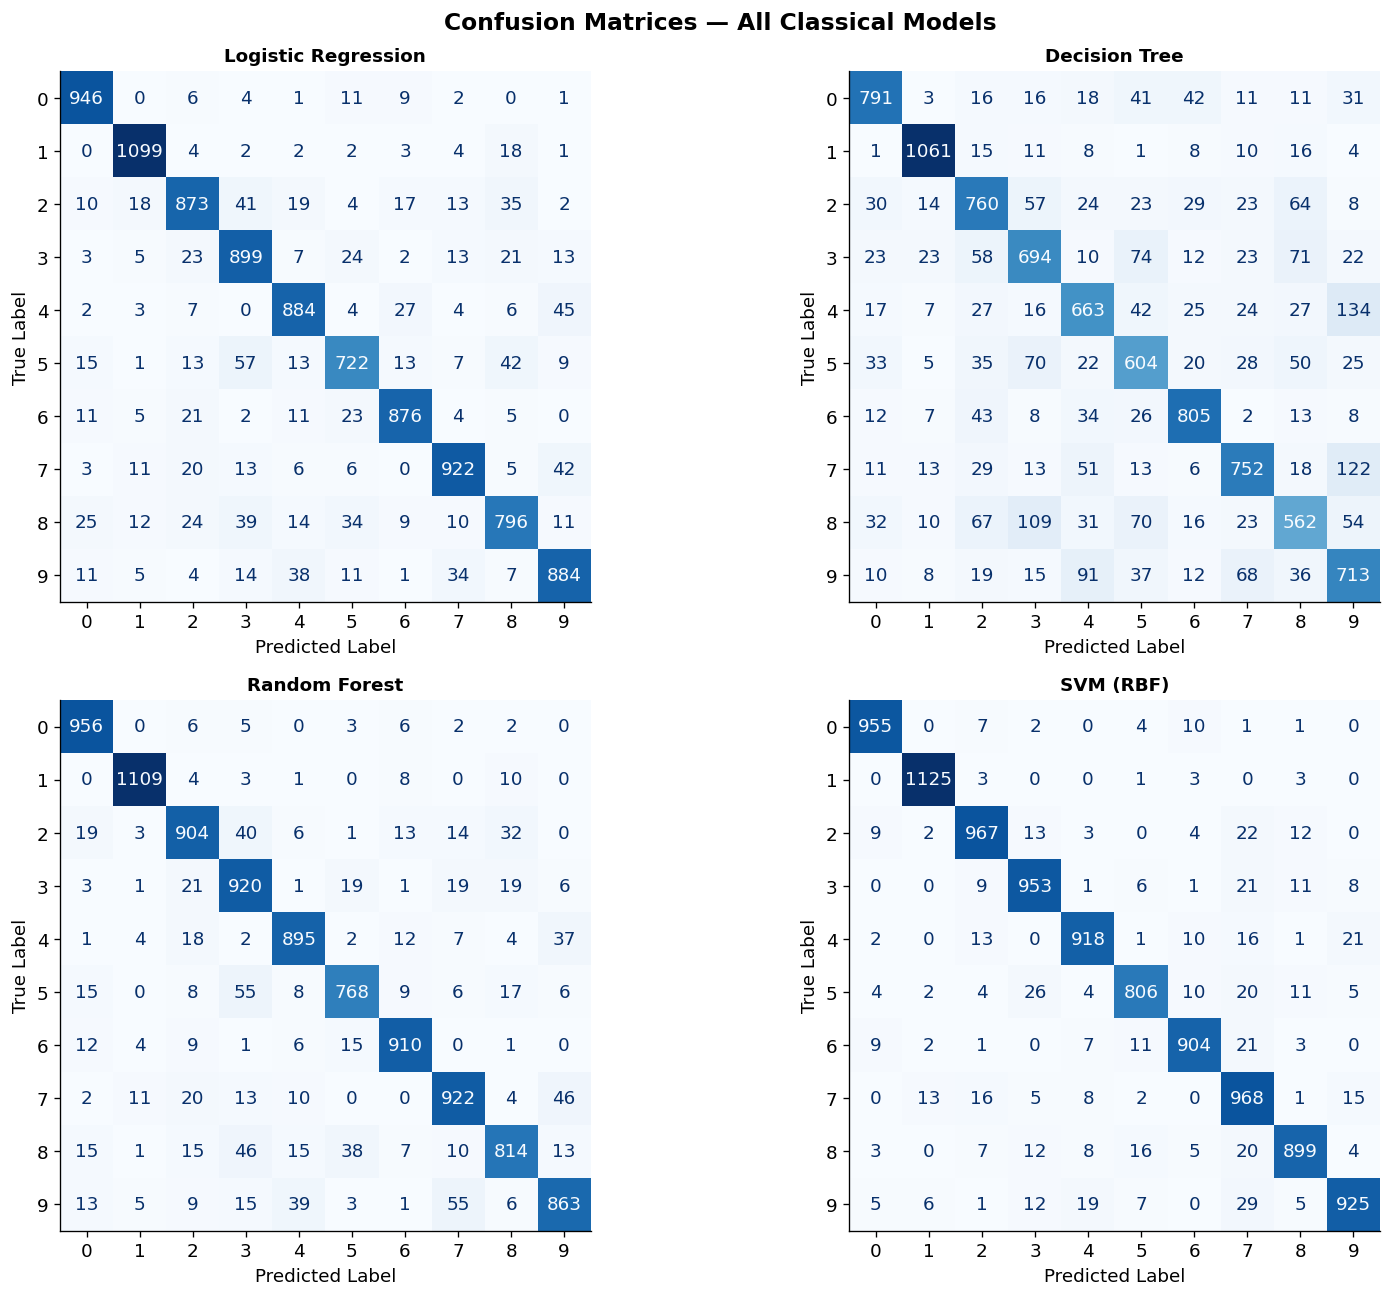


✅ Cell 5 complete — Classical ML done!


In [7]:
# Cell 5: Classical ML Models via sklearn Pipeline + Comparison Table

# ──────────────────────────────────────────────────────────
# USER-DEFINED FUNCTIONS
# ──────────────────────────────────────────────────────────

def build_model_pipeline(classifier):
    """
    Wraps any sklearn classifier into a full Pipeline:
      Step 1 – Flatten images
      Step 2 – Normalize [0,255] → [0,1]
      Step 3 – StandardScaler
      Step 4 – PCA (95% variance)
      Step 5 – Classifier
    Returns an unfitted Pipeline.
    """
    pipe = Pipeline([
        ('flatten'    , FunctionTransformer(flatten_images,   validate=False)),
        ('normalize'  , FunctionTransformer(normalize_images, validate=False)),
        ('scaler'     , StandardScaler()),
        ('pca'        , PCA(n_components=0.95, random_state=SEED)),
        ('classifier' , classifier),
    ])
    return pipe


def evaluate_model(pipe, X_test_raw, y_test, model_name="Model"):
    """
    Generate full classification metrics for a fitted pipeline.
    Returns a dict of metrics.
    """
    y_pred = pipe.predict(X_test_raw)

    # ROC-AUC needs probability scores
    if hasattr(pipe.named_steps['classifier'], 'predict_proba'):
        y_prob = pipe.predict_proba(X_test_raw)
        auc    = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    else:
        auc = None   # SVC without probability=True

    metrics = {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred, average='macro') * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred, average='macro') * 100, 2),
        'F1 Score' : round(f1_score(y_test, y_pred, average='macro') * 100, 2),
        'ROC-AUC'  : round(auc * 100, 2) if auc else 'N/A',
    }
    return metrics, y_pred


def print_metrics(metrics):
    """Pretty-print a single model's metrics."""
    print(f"\n  {'Metric':<12} {'Value':>8}")
    print("  " + "-" * 22)
    for k, v in metrics.items():
        if k != 'Model':
            print(f"  {k:<12} {str(v):>8}%") if v != 'N/A' \
                else print(f"  {k:<12} {'N/A':>8}")


def plot_confusion_matrix_grid(results, X_test_raw, y_test):
    """
    Plot confusion matrices for all models in a 2×2 grid.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle("Confusion Matrices — All Classical Models",
                 fontsize=14, fontweight='bold')

    for ax, (name, pipe) in zip(axes.flatten(), results.items()):
        y_pred = pipe.predict(X_test_raw)
        cm     = confusion_matrix(y_test, y_pred)
        disp   = ConfusionMatrixDisplay(cm, display_labels=range(10))
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(name, fontsize=11, fontweight='bold')
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")

    plt.tight_layout()
    plt.savefig('ml_confusion_matrices.png', bbox_inches='tight', dpi=120)
    plt.show()


def plot_model_comparison(metrics_list):
    """
    Bar chart comparing Accuracy, F1, Precision, Recall across models.
    """
    df_m   = pd.DataFrame(metrics_list)
    models = df_m['Model'].tolist()
    metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

    x     = np.arange(len(models))
    width = 0.2
    colors = ['#2ecc71', '#3498db', '#e67e22', '#9b59b6']

    fig, ax = plt.subplots(figsize=(13, 6))
    for i, (col, color) in enumerate(zip(metric_cols, colors)):
        vals = df_m[col].tolist()
        bars = ax.bar(x + i * width, vals, width, label=col,
                      color=color, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_title("Classical ML Model Comparison\n(Accuracy, Precision, Recall, F1 — %)",
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylabel("Score (%)", fontsize=11)
    ax.set_ylim(80, 102)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('ml_model_comparison.png', bbox_inches='tight', dpi=120)
    plt.show()


def print_comparison_table(metrics_list):
    """Print a formatted model comparison table."""
    df_m = pd.DataFrame(metrics_list)
    df_m = df_m.set_index('Model')
    print("\n" + "=" * 65)
    print("        MODEL PERFORMANCE COMPARISON TABLE")
    print("=" * 65)
    print(df_m.to_string())
    print("=" * 65)
    best = df_m['F1 Score'].idxmax()
    print(f"\n  🏆 Best Classical Model : {best}")
    print(f"     F1 Score             : {df_m.loc[best, 'F1 Score']}%")
    print(f"     Accuracy             : {df_m.loc[best, 'Accuracy']}%")
    return df_m


# ──────────────────────────────────────────────────────────
# DEFINE MODELS  (using 10% of training data for speed;
#                 full data used for CNN in next cell)
# ──────────────────────────────────────────────────────────

# Subsample for classical models (they are slow on 60k samples)
X_tr_sub, _, y_tr_sub, _ = train_test_split(
    X_train_full, y_train_full,
    train_size=0.10, random_state=SEED, stratify=y_train_full
)
print(f"Classical ML training subset : {X_tr_sub.shape[0]:,} samples (10% of train)")
print("(Full 60k used for CNN in Cell 6)\n")

classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, solver='lbfgs',
        multi_class='multinomial', random_state=SEED
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=20, random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=SEED, n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', C=5, gamma='scale', random_state=SEED
    ),
}

# ──────────────────────────────────────────────────────────
# TRAIN ALL MODELS — PIPELINE
# ──────────────────────────────────────────────────────────

print("=" * 55)
print("   SECTION 4 — CLASSICAL ML MODEL TRAINING")
print("=" * 55)

fitted_pipes  = {}
metrics_list  = []

for name, clf in classifiers.items():
    print(f"\n  ▶ Training : {name} ...")
    pipe = build_model_pipeline(clf)
    pipe.fit(X_tr_sub, y_tr_sub)
    fitted_pipes[name] = pipe

    metrics, _ = evaluate_model(pipe, X_test, y_test, model_name=name)
    metrics_list.append(metrics)
    print_metrics(metrics)
    print(f"  ✅ {name} done.")

# ──────────────────────────────────────────────────────────
# COMPARISON TABLE & PLOTS
# ──────────────────────────────────────────────────────────

df_comparison = print_comparison_table(metrics_list)
plot_model_comparison(metrics_list)
plot_confusion_matrix_grid(fitted_pipes, X_test, y_test)

print("\n✅ Cell 5 complete — Classical ML done!")

  SECTION 5A — HYPERPARAMETER TUNING (Random Forest)

  Tuning Random Forest via RandomizedSearchCV ...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

  Best RF Params : {'classifier__n_estimators': 150, 'classifier__min_samples_split': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None}
  Best CV Score  : 89.67%

  Before Tuning:

  Metric          Value
  ----------------------
  Accuracy        90.61%
  Precision       90.58%
  Recall           90.5%
  F1 Score         90.5%
  ROC-AUC         99.06%

  After Tuning:

  Metric          Value
  ----------------------
  Accuracy        90.88%
  Precision       90.83%
  Recall          90.76%
  F1 Score        90.77%
  ROC-AUC         99.14%


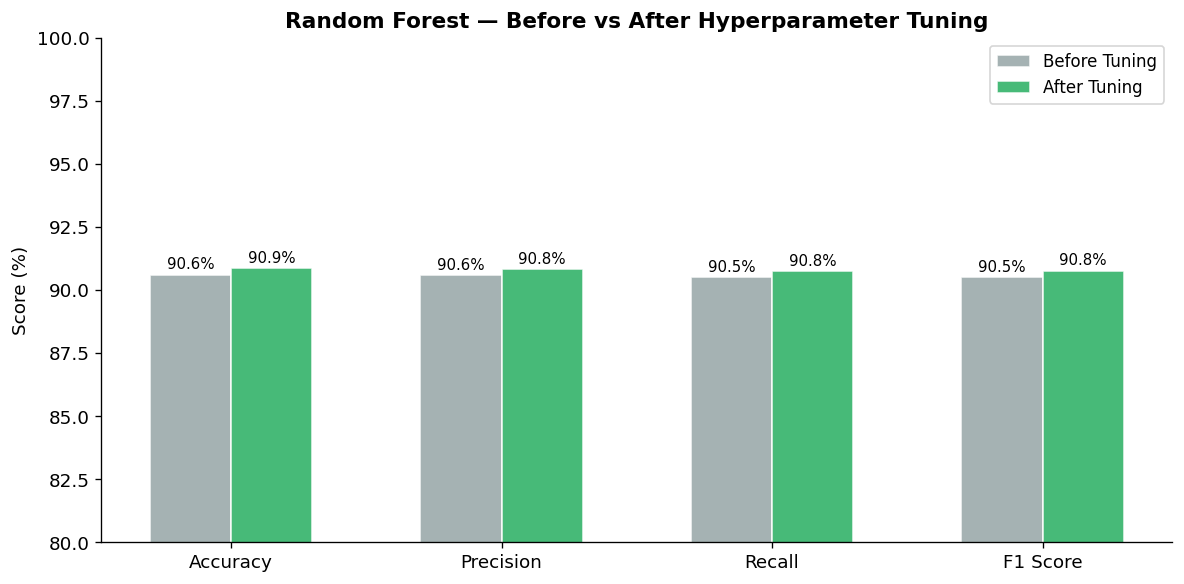


  SECTION 5B — ANN (6 Hidden Layers) EXPERIMENTS

  ANN Train : 51,000  |  Val : 9,000  |  Test : 10,000


──────────────────────────────────────────────────
  Experiment : ADAM  lr=0.001
──────────────────────────────────────────────────
Epoch 1/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8369 - loss: 0.5426 - val_accuracy: 0.9459 - val_loss: 0.1916 - learning_rate: 0.0010
Epoch 2/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9426 - loss: 0.2101 - val_accuracy: 0.9646 - val_loss: 0.1359 - learning_rate: 0.0010
Epoch 3/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9556 - loss: 0.1633 - val_accuracy: 0.9651 - val_loss: 0.1293 - learning_rate: 0.0010
Epoch 4/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9625 - loss: 0.1349 - val_accuracy: 0.9680 - val_loss: 0.1229 - learning_rate: 0.0010
Epoch 5/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9665 - loss: 0.1198 - val_accuracy: 0.9714 - val_loss: 0.1135 - learning_rate: 0.0010


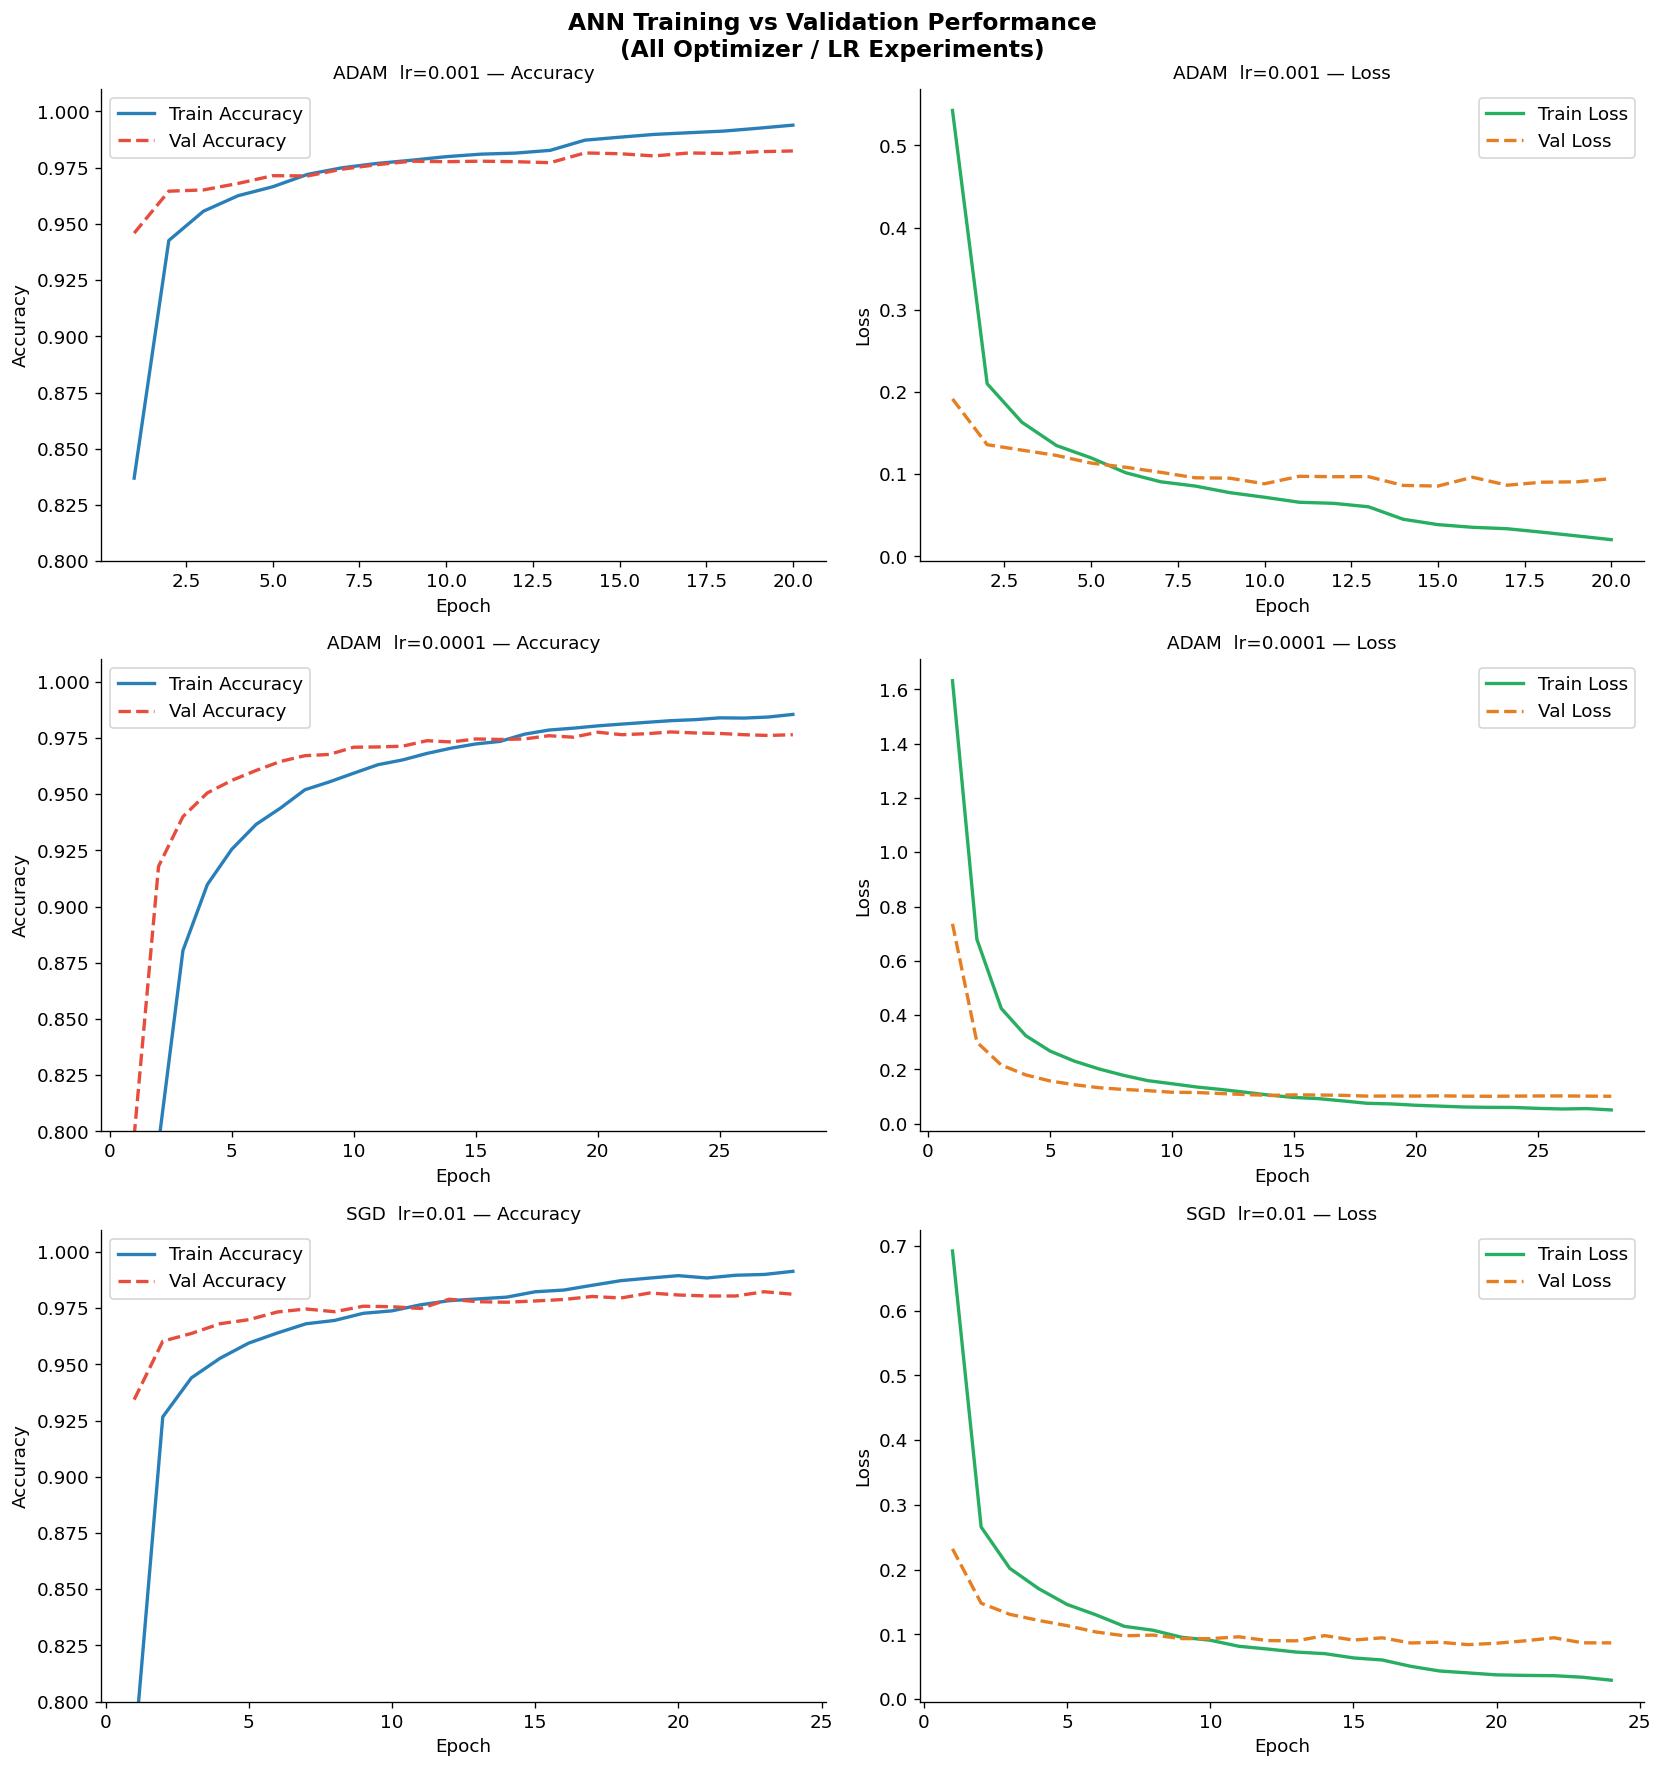


  Best Optimizer    : SGD
  Best Learning Rate: 0.01

✅ Cell 6 complete — Tuning + ANN done!


In [8]:
# Cell 6: Hyperparameter Tuning + ANN with 6 Hidden Layers

# ──────────────────────────────────────────────────────────
# USER-DEFINED FUNCTIONS — HYPERPARAMETER TUNING
# ──────────────────────────────────────────────────────────

def tune_random_forest(X_train, y_train):
    """
    RandomizedSearchCV on Random Forest inside a Pipeline.
    Returns best estimator and best params.
    """
    pipe_rf = Pipeline([
        ('flatten'   , FunctionTransformer(flatten_images,   validate=False)),
        ('normalize' , FunctionTransformer(normalize_images, validate=False)),
        ('scaler'    , StandardScaler()),
        ('pca'       , PCA(n_components=0.95, random_state=SEED)),
        ('classifier', RandomForestClassifier(random_state=SEED, n_jobs=-1)),
    ])

    param_dist = {
        'classifier__n_estimators' : [50, 100, 150],
        'classifier__max_depth'    : [10, 20, None],
        'classifier__min_samples_split': [2, 5],
        'classifier__max_features' : ['sqrt', 'log2'],
    }

    search = RandomizedSearchCV(
        pipe_rf, param_dist,
        n_iter=8, cv=3, scoring='accuracy',
        random_state=SEED, n_jobs=-1, verbose=1
    )
    search.fit(X_train, y_train)
    print(f"\n  Best RF Params : {search.best_params_}")
    print(f"  Best CV Score  : {search.best_score_*100:.2f}%")
    return search.best_estimator_


def compare_before_after_tuning(before_metrics, after_metrics):
    """
    Print and plot before vs after tuning comparison for Random Forest.
    """
    labels  = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    before  = [before_metrics[m] for m in labels]
    after   = [after_metrics[m]  for m in labels]

    x     = np.arange(len(labels))
    width = 0.3

    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - width/2, before, width, label='Before Tuning',
                color='#95a5a6', alpha=0.85, edgecolor='white')
    b2 = ax.bar(x + width/2, after,  width, label='After Tuning',
                color='#27ae60', alpha=0.85, edgecolor='white')

    for bars in [b1, b2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.1,
                    f'{bar.get_height():.1f}%',
                    ha='center', va='bottom', fontsize=9)

    ax.set_title("Random Forest — Before vs After Hyperparameter Tuning",
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel("Score (%)", fontsize=11)
    ax.set_ylim(80, 100)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('tuning_comparison.png', bbox_inches='tight', dpi=120)
    plt.show()


# ──────────────────────────────────────────────────────────
# USER-DEFINED FUNCTIONS — ANN
# ──────────────────────────────────────────────────────────

def build_ann_model(optimizer='adam', learning_rate=0.001):
    """
    Build ANN with minimum 6 hidden layers.
    Architecture:
      Input  → Flatten → Dense(512) → Dense(256) → Dense(128)
             → Dense(64) → Dense(64) → Dense(32) → Output(10)
    Activation : ReLU (hidden), Softmax (output)
    Returns compiled Keras model.
    """
    if optimizer == 'adam':
        opt = optimizers.Adam(learning_rate=learning_rate)
    else:
        opt = optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

    model = models.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        # Hidden Layer 1
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        # Hidden Layer 2
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        # Hidden Layer 3
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        # Hidden Layer 4
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        # Hidden Layer 5
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        # Hidden Layer 6
        layers.Dense(32, activation='relu'),
        # Output Layer
        layers.Dense(10, activation='softmax'),
    ], name=f"ANN_{optimizer}_lr{learning_rate}")

    model.compile(
        optimizer  = opt,
        loss       = 'sparse_categorical_crossentropy',
        metrics    = ['accuracy']
    )
    return model


def train_ann_model(model, X_train, y_train, X_val, y_val,
                    epochs=30, batch_size=128):
    """
    Train ANN with EarlyStopping and ReduceLROnPlateau callbacks.
    Returns history object.
    """
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=0),
    ]
    history = model.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        epochs          = epochs,
        batch_size      = batch_size,
        callbacks       = callbacks,
        verbose         = 1,
    )
    return history


def evaluate_ann(model, X_test, y_test, model_name="ANN"):
    """Evaluate ANN and return metrics dict."""
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    auc    = roc_auc_score(y_test, y_prob,
                           multi_class='ovr', average='macro')
    metrics = {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_test, y_pred)  * 100, 2),
        'Precision': round(precision_score(y_test, y_pred,
                           average='macro') * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred,
                           average='macro') * 100, 2),
        'F1 Score' : round(f1_score(y_test, y_pred,
                           average='macro') * 100, 2),
        'ROC-AUC'  : round(auc * 100, 2),
    }
    return metrics


def plot_ann_training_history(histories_dict):
    """
    Plot training vs validation accuracy AND loss for all ANN experiments.
    One row per experiment: [Accuracy plot | Loss plot].
    """
    n     = len(histories_dict)
    fig, axes = plt.subplots(n, 2, figsize=(14, 5 * n))
    if n == 1:
        axes = [axes]
    fig.suptitle("ANN Training vs Validation Performance\n"
                 "(All Optimizer / LR Experiments)",
                 fontsize=14, fontweight='bold')

    for row, (name, history) in enumerate(histories_dict.items()):
        ep  = range(1, len(history.history['accuracy']) + 1)

        # Accuracy
        axes[row][0].plot(ep, history.history['accuracy'],
                          label='Train Accuracy', color='#2980b9', linewidth=2)
        axes[row][0].plot(ep, history.history['val_accuracy'],
                          label='Val Accuracy',   color='#e74c3c',
                          linewidth=2, linestyle='--')
        axes[row][0].set_title(f"{name} — Accuracy", fontsize=11)
        axes[row][0].set_xlabel("Epoch"); axes[row][0].set_ylabel("Accuracy")
        axes[row][0].legend(); axes[row][0].set_ylim(0.8, 1.01)

        # Loss
        axes[row][1].plot(ep, history.history['loss'],
                          label='Train Loss', color='#27ae60', linewidth=2)
        axes[row][1].plot(ep, history.history['val_loss'],
                          label='Val Loss',   color='#e67e22',
                          linewidth=2, linestyle='--')
        axes[row][1].set_title(f"{name} — Loss", fontsize=11)
        axes[row][1].set_xlabel("Epoch"); axes[row][1].set_ylabel("Loss")
        axes[row][1].legend()

    plt.tight_layout()
    plt.savefig('ann_training_history.png', bbox_inches='tight', dpi=120)
    plt.show()


def print_ann_comparison(ann_metrics_list):
    """Print ANN experiment comparison table."""
    df_ann = pd.DataFrame(ann_metrics_list).set_index('Model')
    print("\n" + "=" * 70)
    print("        ANN EXPERIMENT COMPARISON TABLE")
    print("=" * 70)
    print(df_ann.to_string())
    print("=" * 70)
    best = df_ann['F1 Score'].idxmax()
    print(f"\n  🏆 Best ANN Config : {best}")
    print(f"     Accuracy        : {df_ann.loc[best, 'Accuracy']}%")
    print(f"     F1 Score        : {df_ann.loc[best, 'F1 Score']}%")
    return df_ann, best


# ──────────────────────────────────────────────────────────
# STEP 1 — HYPERPARAMETER TUNING (Random Forest)
# ──────────────────────────────────────────────────────────

print("=" * 55)
print("  SECTION 5A — HYPERPARAMETER TUNING (Random Forest)")
print("=" * 55)

print("\n  Tuning Random Forest via RandomizedSearchCV ...")
best_rf_pipe = tune_random_forest(X_tr_sub, y_tr_sub)

# Before tuning metrics (from Cell 5)
before_rf = next(m for m in metrics_list if m['Model'] == 'Random Forest')

# After tuning metrics
after_rf_raw, _ = evaluate_model(best_rf_pipe, X_test, y_test,
                                  model_name='RF Tuned')
print("\n  Before Tuning:"); print_metrics(before_rf)
print("\n  After Tuning:");  print_metrics(after_rf_raw)
compare_before_after_tuning(before_rf, after_rf_raw)

# ──────────────────────────────────────────────────────────
# STEP 2 — ANN EXPERIMENTS (Optimizer × Learning Rate)
# ──────────────────────────────────────────────────────────

print("\n" + "=" * 55)
print("  SECTION 5B — ANN (6 Hidden Layers) EXPERIMENTS")
print("=" * 55)

# Train/Val split from normalized images (no flattening — ANN takes 28x28)
X_tr_ann, X_val_ann, y_tr_ann, y_val_ann = train_test_split(
    X_train_norm, y_train_full,
    test_size=0.15, random_state=SEED, stratify=y_train_full
)
print(f"\n  ANN Train : {X_tr_ann.shape[0]:,}  |  "
      f"Val : {X_val_ann.shape[0]:,}  |  "
      f"Test : {X_test_norm.shape[0]:,}\n")

# Experiment configurations
experiments = [
    {'optimizer': 'adam', 'learning_rate': 0.001},
    {'optimizer': 'adam', 'learning_rate': 0.0001},
    {'optimizer': 'sgd',  'learning_rate': 0.01},
]

ann_histories = {}
ann_metrics_list = []

for exp in experiments:
    opt = exp['optimizer']
    lr  = exp['learning_rate']
    name = f"{opt.upper()}  lr={lr}"
    print(f"\n{'─'*50}")
    print(f"  Experiment : {name}")
    print(f"{'─'*50}")

    model   = build_ann_model(optimizer=opt, learning_rate=lr)
    history = train_ann_model(model,
                               X_tr_ann, y_tr_ann,
                               X_val_ann, y_val_ann,
                               epochs=30, batch_size=128)

    metrics = evaluate_ann(model, X_test_norm, y_test, model_name=name)
    ann_metrics_list.append(metrics)
    ann_histories[name] = history

    print(f"\n  Test Results — {name}")
    print_metrics(metrics)

# ──────────────────────────────────────────────────────────
# RESULTS — PLOTS & TABLES
# ──────────────────────────────────────────────────────────

df_ann, best_ann_name = print_ann_comparison(ann_metrics_list)
plot_ann_training_history(ann_histories)

# Store best ANN config for CNN cell
best_ann_exp = next(e for e in experiments
                    if f"{e['optimizer'].upper()}  lr={e['learning_rate']}"
                    == best_ann_name)
print(f"\n  Best Optimizer    : {best_ann_exp['optimizer'].upper()}")
print(f"  Best Learning Rate: {best_ann_exp['learning_rate']}")
print("\n✅ Cell 6 complete — Tuning + ANN done!")

  SECTION 6 — CNN MODEL TRAINING

  CNN Train : 51,000  |  Val : 9,000  |  Test : 10,000


Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,29

 Total params: 1,781,226 (6.79 MB)

 Trainable params: 1,780,074 (6.79 MB)

 Non-trainable params: 1,152 (4.50 KB)


  Training CNN ...
Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.9262 - loss: 0.2351 - val_accuracy: 0.9297 - val_loss: 0.2355 - learning_rate: 0.0100
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.9769 - loss: 0.0737 - val_accuracy: 0.9890 - val_loss: 0.0388 - learning_rate: 0.0100
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step - accuracy: 0.9838 - loss: 0.0531 - val_accuracy: 0.9889 - val_loss: 0.0392 - learning_rate: 0.0100
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9861 - loss: 0.0449 - val_accuracy: 0.9908 - val_loss: 0.0329 - learning_rate: 0.0100
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9881 - loss: 0.0385 - val_accuracy: 0.9910 - val_loss: 0.0318 - learning_rate: 0.0100
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9895 - loss: 0.0330 - val_accuracy: 0.9914 - val_loss: 0.0301 - learning_rate: 0.0100
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - 

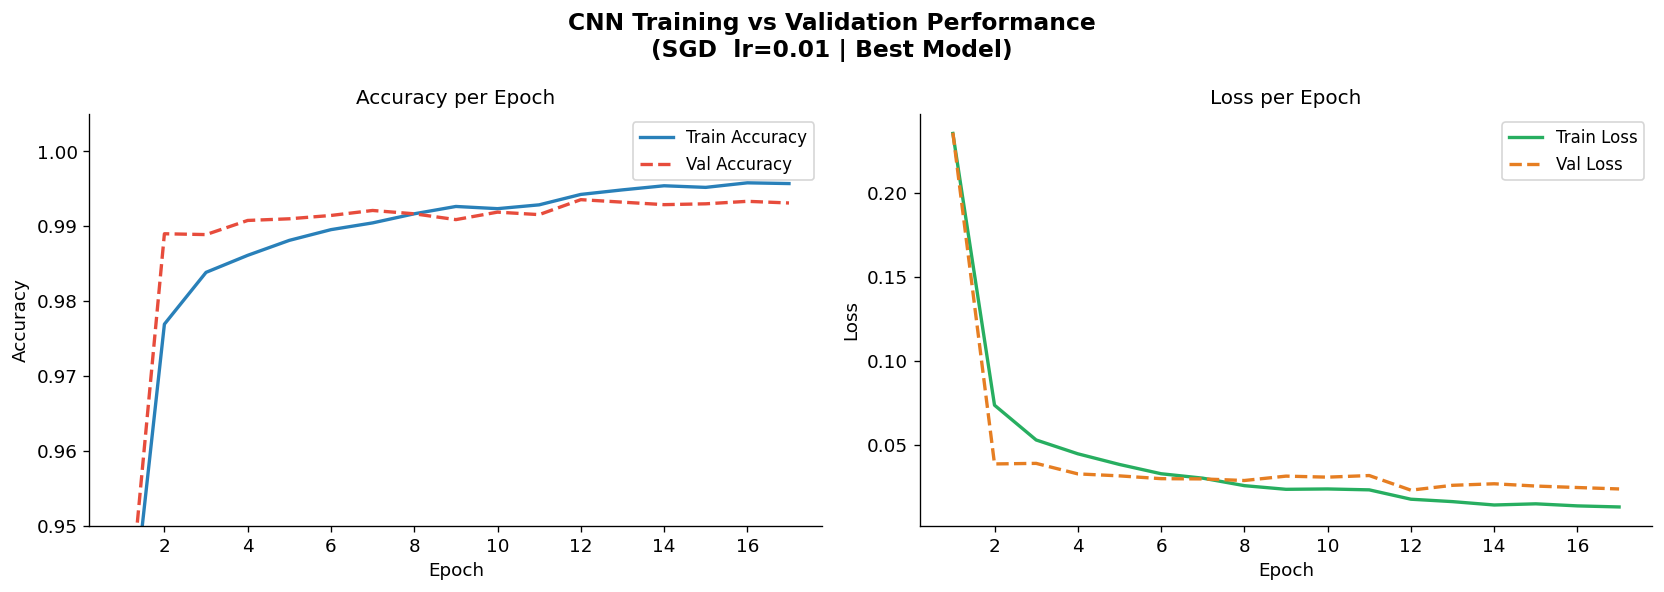

✅ Saved: cnn_training_performance.png  (required deliverable)


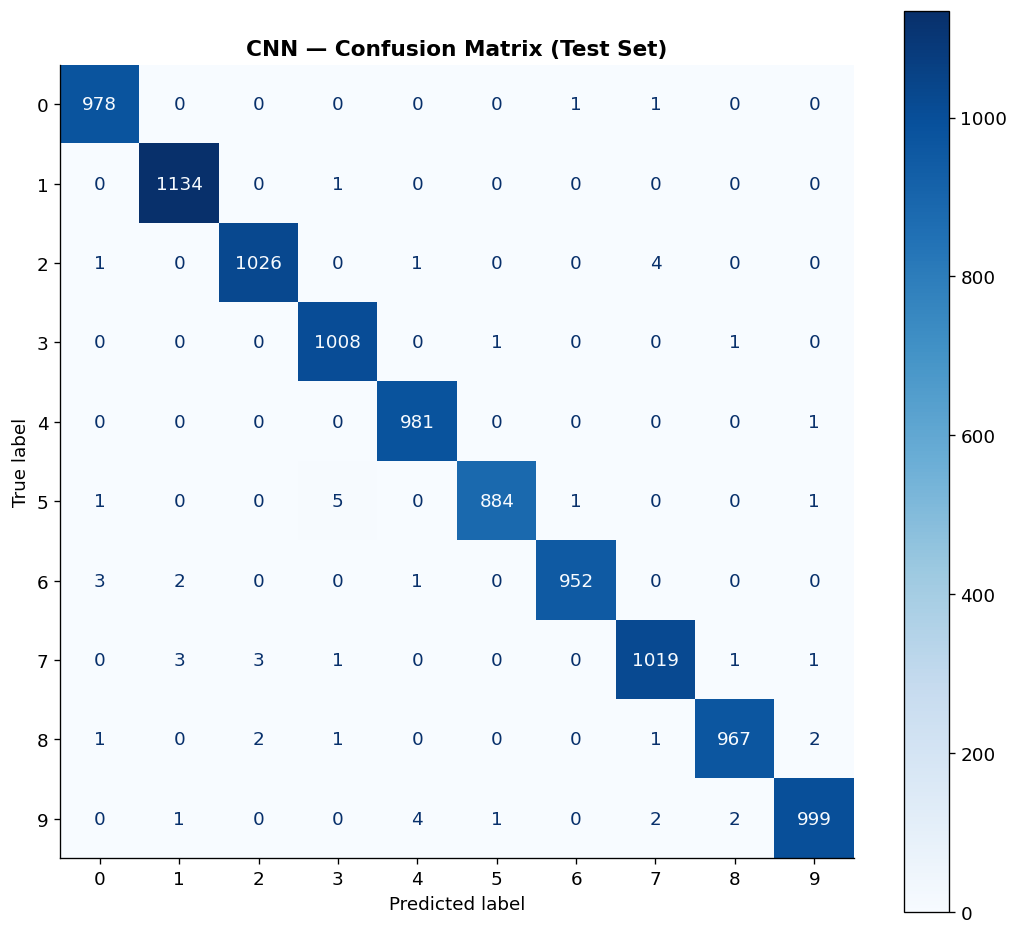


  Building Master Comparison Table ...

        MASTER MODEL COMPARISON TABLE — ALL MODELS
  Model                            Acc    Prec     Rec      F1     AUC
  ------------------------------------------------------------
  Logistic Regression            89.01   88.88   88.84   88.83   98.63
  Decision Tree                  74.05   73.79   73.73   73.71   85.39
  Random Forest                  90.61   90.58    90.5    90.5   99.06
  SVM (RBF)                       94.2   94.26    94.1   94.15     N/A
  ADAM  lr=0.001                 98.28   98.27   98.27   98.27   99.97
  ADAM  lr=0.0001                97.84   97.84   97.83   97.83   99.95
  SGD  lr=0.01                   98.31    98.3   98.29    98.3   99.97
  CNN (SGD lr=0.01)              99.48   99.49   99.47   99.48   100.0

  🏆 BEST OVERALL MODEL : CNN (SGD lr=0.01)
     Accuracy           : 99.48%
     F1 Score           : 99.48%
     ROC-AUC            : 100.0%


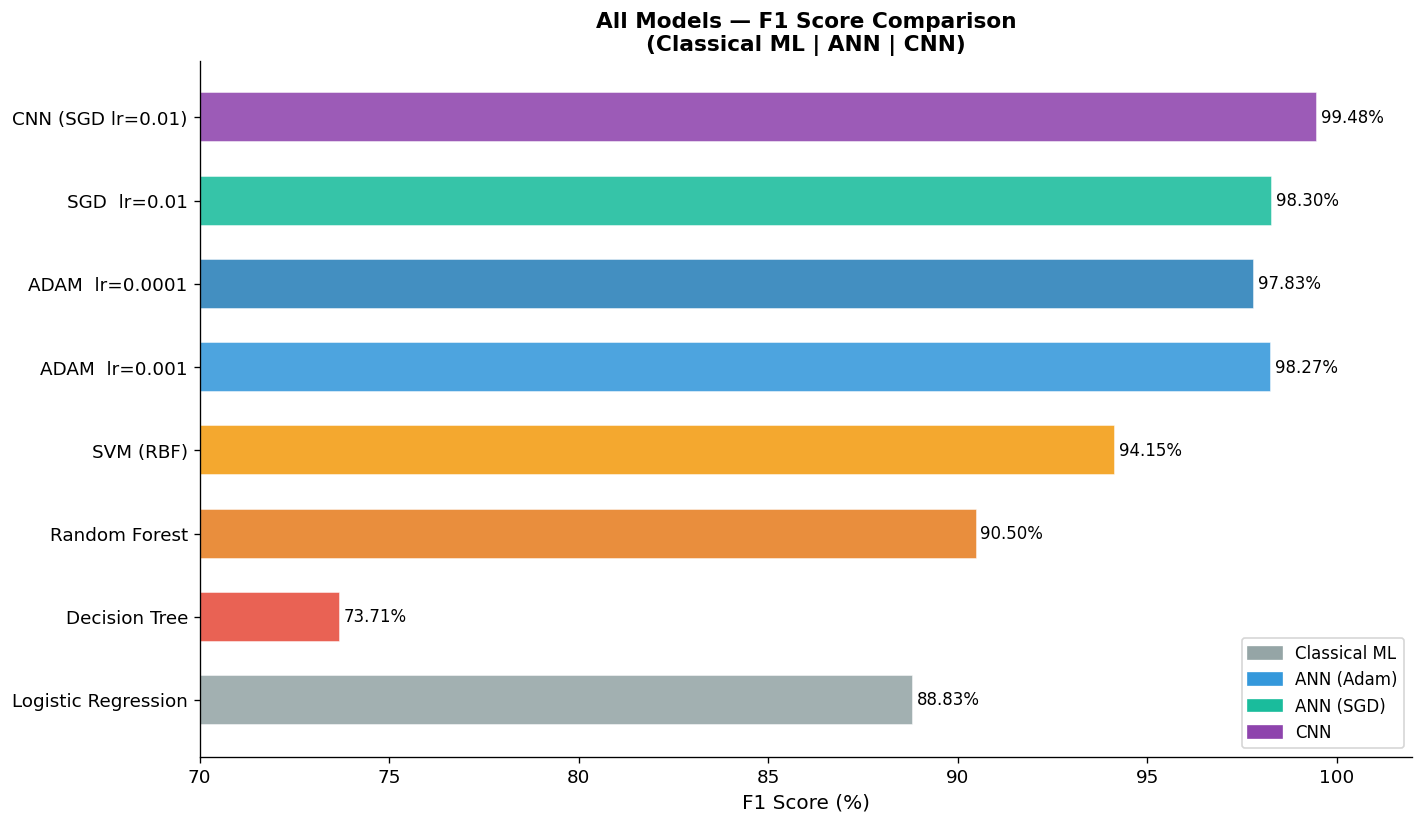


✅ Cell 7 complete — CNN trained & all models compared!


In [9]:
# Cell 7: CNN Model + Master Comparison Table + Final Evaluation

# ──────────────────────────────────────────────────────────
# USER-DEFINED FUNCTIONS — CNN
# ──────────────────────────────────────────────────────────

def build_cnn_model(optimizer='sgd', learning_rate=0.01):
    """
    Build CNN model for MNIST classification.
    Architecture:
      Input(28,28,1)
      → Conv2D(32, 3×3, ReLU) → BatchNorm → MaxPool(2×2)
      → Conv2D(64, 3×3, ReLU) → BatchNorm → MaxPool(2×2)
      → Conv2D(64, 3×3, ReLU) → BatchNorm
      → Flatten
      → Dense(128, ReLU) → Dropout(0.3)
      → Dense(10, Softmax)
    Returns compiled Keras model.
    """
    if optimizer == 'sgd':
        opt = optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        opt = optimizers.Adam(learning_rate=learning_rate)

    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # Conv Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Conv Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Conv Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        # Fully Connected Head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax'),
    ], name="MNIST_CNN")

    model.compile(
        optimizer = opt,
        loss      = 'sparse_categorical_crossentropy',
        metrics   = ['accuracy']
    )
    return model


def train_cnn_model(model, X_train, y_train, X_val, y_val,
                    epochs=20, batch_size=128):
    """
    Train CNN with EarlyStopping + ReduceLROnPlateau callbacks.
    Returns history object.
    """
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1),
    ]
    history = model.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        epochs          = epochs,
        batch_size      = batch_size,
        callbacks       = callbacks,
        verbose         = 1,
    )
    return history


def plot_cnn_training_history(history):
    """
    Plot CNN training vs validation — Accuracy and Loss side by side.
    Required deliverable: CNN training performance graph.
    """
    ep = range(1, len(history.history['accuracy']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("CNN Training vs Validation Performance\n"
                 "(SGD  lr=0.01 | Best Model)",
                 fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(ep, history.history['accuracy'],
                 label='Train Accuracy', color='#2980b9', linewidth=2)
    axes[0].plot(ep, history.history['val_accuracy'],
                 label='Val Accuracy', color='#e74c3c',
                 linewidth=2, linestyle='--')
    axes[0].set_title("Accuracy per Epoch", fontsize=12)
    axes[0].set_xlabel("Epoch", fontsize=11)
    axes[0].set_ylabel("Accuracy", fontsize=11)
    axes[0].legend(fontsize=10)
    axes[0].set_ylim(0.95, 1.005)

    # Loss
    axes[1].plot(ep, history.history['loss'],
                 label='Train Loss', color='#27ae60', linewidth=2)
    axes[1].plot(ep, history.history['val_loss'],
                 label='Val Loss', color='#e67e22',
                 linewidth=2, linestyle='--')
    axes[1].set_title("Loss per Epoch", fontsize=12)
    axes[1].set_xlabel("Epoch", fontsize=11)
    axes[1].set_ylabel("Loss", fontsize=11)
    axes[1].legend(fontsize=10)

    plt.tight_layout()
    plt.savefig('cnn_training_performance.png', bbox_inches='tight', dpi=120)
    plt.show()
    print("✅ Saved: cnn_training_performance.png  (required deliverable)")


def plot_cnn_confusion_matrix(model, X_test, y_test):
    """Plot confusion matrix for the CNN model."""
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    cm   = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(9, 8))
    disp = ConfusionMatrixDisplay(cm, display_labels=range(10))
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title("CNN — Confusion Matrix (Test Set)", fontsize=13,
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig('cnn_confusion_matrix.png', bbox_inches='tight', dpi=120)
    plt.show()
    return y_pred, y_prob


def print_master_comparison(classical_metrics, ann_metrics, cnn_metrics):
    """
    Print the master model comparison table:
    Classical ML + ANN experiments + CNN — all in one table.
    """
    all_metrics = classical_metrics + ann_metrics + [cnn_metrics]
    df_all      = pd.DataFrame(all_metrics).set_index('Model')

    print("\n" + "=" * 72)
    print("        MASTER MODEL COMPARISON TABLE — ALL MODELS")
    print("=" * 72)
    print(f"  {'Model':<28} {'Acc':>7} {'Prec':>7} "
          f"{'Rec':>7} {'F1':>7} {'AUC':>7}")
    print("  " + "-" * 60)
    for model_name, row in df_all.iterrows():
        auc_str = f"{row['ROC-AUC']:>7}" if row['ROC-AUC'] != 'N/A' \
                  else f"{'N/A':>7}"
        print(f"  {model_name:<28} "
              f"{row['Accuracy']:>7} "
              f"{row['Precision']:>7} "
              f"{row['Recall']:>7} "
              f"{row['F1 Score']:>7} "
              f"{auc_str}")
    print("=" * 72)

    best_model = df_all['F1 Score'].idxmax()
    best_f1    = df_all.loc[best_model, 'F1 Score']
    best_acc   = df_all.loc[best_model, 'Accuracy']
    best_auc   = df_all.loc[best_model, 'ROC-AUC']
    print(f"\n  🏆 BEST OVERALL MODEL : {best_model}")
    print(f"     Accuracy           : {best_acc}%")
    print(f"     F1 Score           : {best_f1}%")
    print(f"     ROC-AUC            : {best_auc}%")
    return df_all


def plot_master_comparison(df_all):
    """
    Horizontal bar chart — F1 Score for all models.
    Color-coded by model family.
    """
    colors_map = {
        'Logistic Regression' : '#95a5a6',
        'Decision Tree'       : '#e74c3c',
        'Random Forest'       : '#e67e22',
        'SVM (RBF)'           : '#f39c12',
        'ADAM  lr=0.001'      : '#3498db',
        'ADAM  lr=0.0001'     : '#2980b9',
        'SGD  lr=0.01'        : '#1abc9c',
        'CNN (SGD lr=0.01)'   : '#8e44ad',
    }

    models_list = df_all.index.tolist()
    f1_scores   = df_all['F1 Score'].tolist()
    bar_colors  = [colors_map.get(m, '#7f8c8d') for m in models_list]

    fig, ax = plt.subplots(figsize=(12, 7))
    bars = ax.barh(models_list, f1_scores, color=bar_colors,
                   alpha=0.88, edgecolor='white', height=0.6)

    for bar, val in zip(bars, f1_scores):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', fontsize=10)

    ax.set_xlim(70, 102)
    ax.set_xlabel("F1 Score (%)", fontsize=12)
    ax.set_title("All Models — F1 Score Comparison\n"
                 "(Classical ML | ANN | CNN)",
                 fontsize=13, fontweight='bold')

    # Legend patches
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(color='#95a5a6', label='Classical ML'),
        Patch(color='#3498db', label='ANN (Adam)'),
        Patch(color='#1abc9c', label='ANN (SGD)'),
        Patch(color='#8e44ad', label='CNN'),
    ]
    ax.legend(handles=legend_elements, fontsize=10, loc='lower right')
    plt.tight_layout()
    plt.savefig('master_model_comparison.png', bbox_inches='tight', dpi=120)
    plt.show()


# ──────────────────────────────────────────────────────────
# TRAIN CNN
# ──────────────────────────────────────────────────────────

print("=" * 55)
print("  SECTION 6 — CNN MODEL TRAINING")
print("=" * 55)

# CNN train/val split (uses full 60k, CNN-shaped arrays)
X_tr_cnn, X_val_cnn, y_tr_cnn, y_val_cnn = train_test_split(
    X_train_cnn, y_train_full,
    test_size=0.15, random_state=SEED, stratify=y_train_full
)
print(f"\n  CNN Train : {X_tr_cnn.shape[0]:,}  |  "
      f"Val : {X_val_cnn.shape[0]:,}  |  "
      f"Test : {X_test_cnn.shape[0]:,}")

cnn_model = build_cnn_model(optimizer='sgd', learning_rate=0.01)
cnn_model.summary()

print("\n  Training CNN ...")
cnn_history = train_cnn_model(
    cnn_model,
    X_tr_cnn, y_tr_cnn,
    X_val_cnn, y_val_cnn,
    epochs=20, batch_size=128
)

# ──────────────────────────────────────────────────────────
# EVALUATE CNN
# ──────────────────────────────────────────────────────────

print("\n  Evaluating CNN on Test Set ...")
cnn_metrics = evaluate_ann(cnn_model, X_test_cnn, y_test,
                            model_name='CNN (SGD lr=0.01)')
print("\n  CNN Test Results:")
print_metrics(cnn_metrics)

# CNN required plots
plot_cnn_training_history(cnn_history)
y_pred_cnn, y_prob_cnn = plot_cnn_confusion_matrix(cnn_model, X_test_cnn, y_test)

# ──────────────────────────────────────────────────────────
# MASTER COMPARISON TABLE
# ──────────────────────────────────────────────────────────

print("\n  Building Master Comparison Table ...")
df_master = print_master_comparison(
    metrics_list,         # Classical ML (from Cell 5)
    ann_metrics_list,     # ANN experiments (from Cell 6)
    cnn_metrics           # CNN (just trained)
)
plot_master_comparison(df_master)

print("\n✅ Cell 7 complete — CNN trained & all models compared!")

  SECTION 6 — FINAL MODEL EVALUATION & INTERPRETATION

  Plotting ROC Curve ...


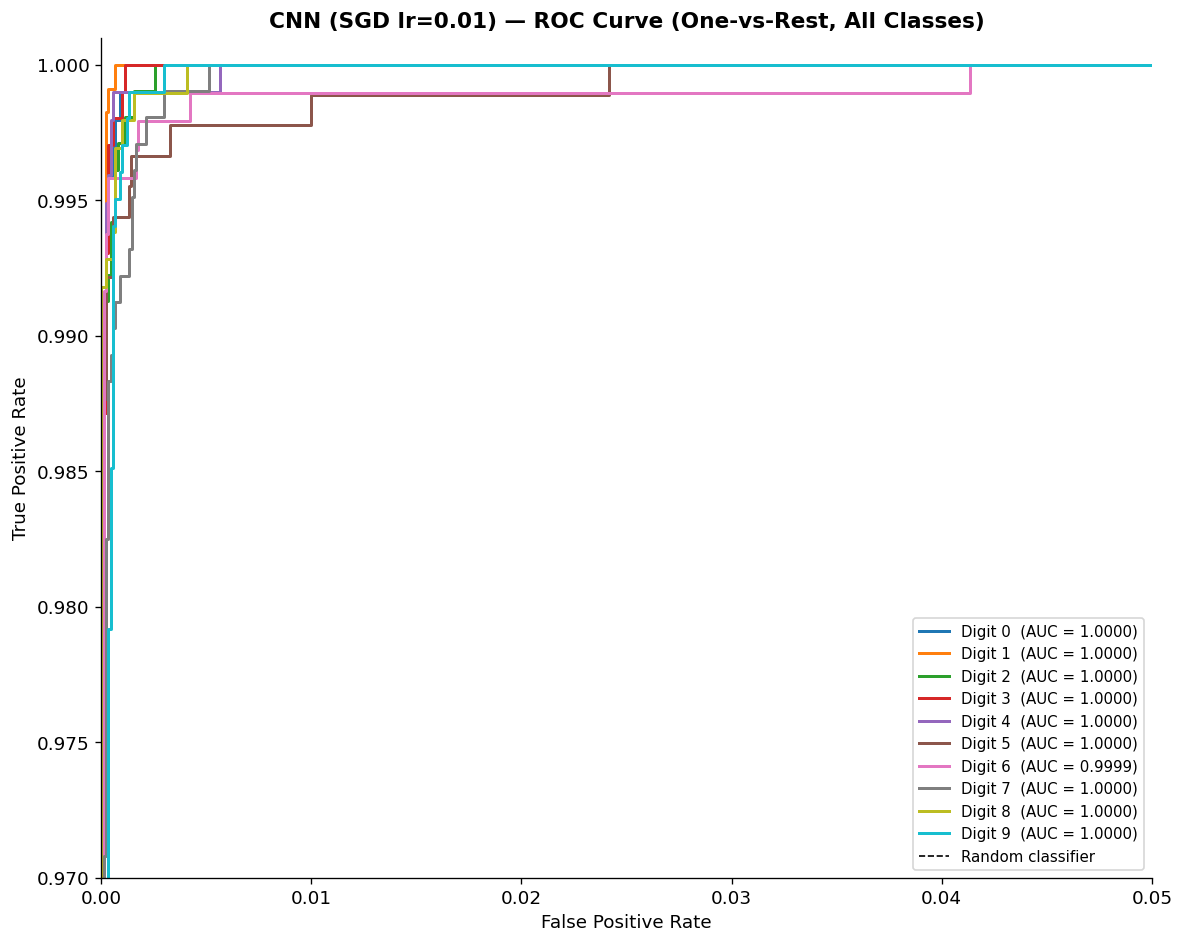


  FINAL MODEL — FULL CLASSIFICATION REPORT (CNN)
              precision    recall  f1-score   support

     Digit 0       0.99      1.00      1.00       980
     Digit 1       0.99      1.00      1.00      1135
     Digit 2       1.00      0.99      0.99      1032
     Digit 3       0.99      1.00      1.00      1010
     Digit 4       0.99      1.00      1.00       982
     Digit 5       1.00      0.99      0.99       892
     Digit 6       1.00      0.99      1.00       958
     Digit 7       0.99      0.99      0.99      1028
     Digit 8       1.00      0.99      0.99       974
     Digit 9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


  Running predictions on synthetic sample set ...


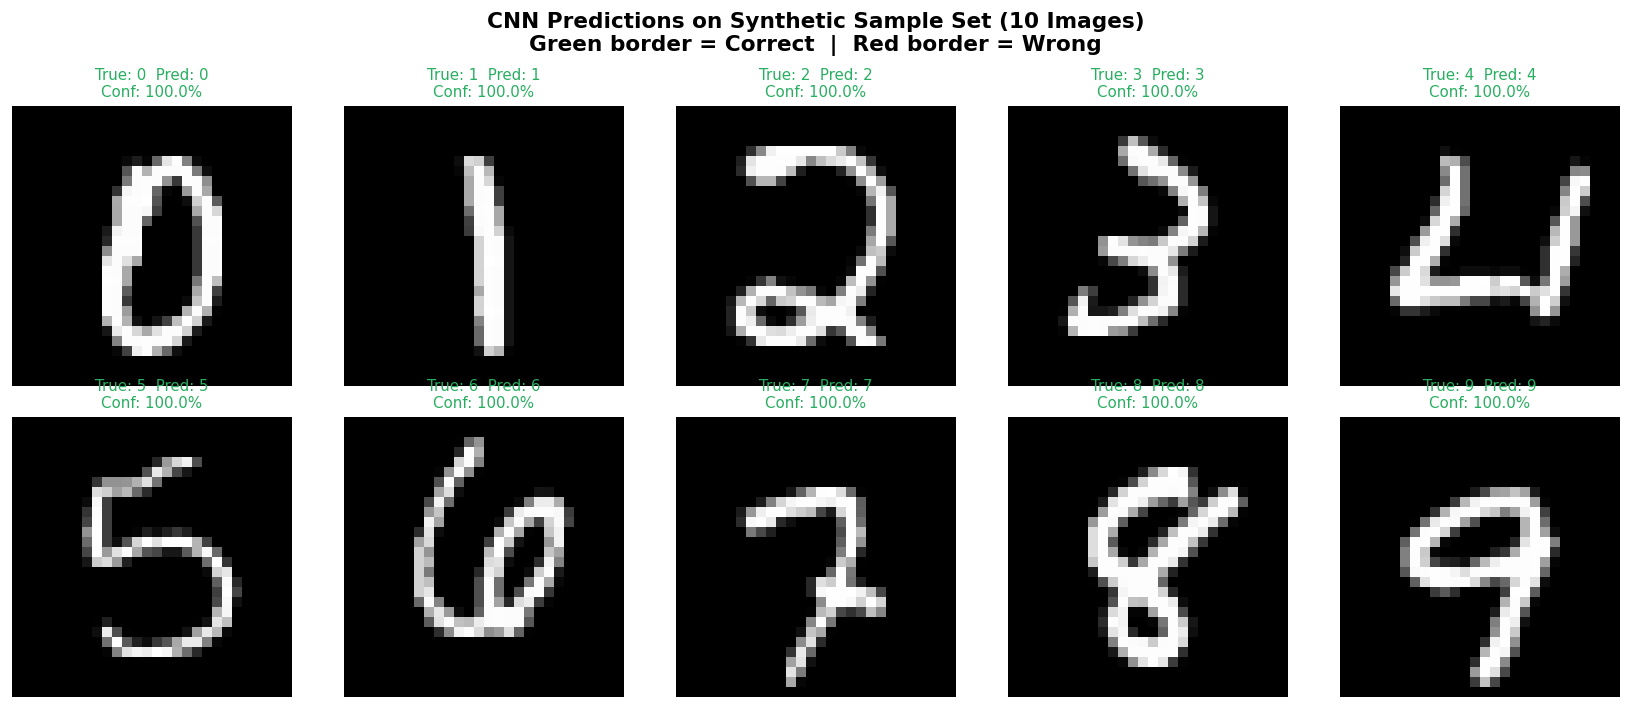


   SYNTHETIC SAMPLE PREDICTION RESULTS (CNN)
 Sample #  True Label  Predicted  Confidence % Correct?
        1           0          0    100.000000        ✅
        2           1          1    100.000000        ✅
        3           2          2    100.000000        ✅
        4           3          3    100.000000        ✅
        5           4          4    100.000000        ✅
        6           5          5    100.000000        ✅
        7           6          6    100.000000        ✅
        8           7          7     99.989998        ✅
        9           8          8    100.000000        ✅
       10           9          9    100.000000        ✅

  Correct predictions : 10 / 10
  Sample Accuracy     : 100.0%
  Mean Confidence     : 100.00%

  SECTION 6 — BUSINESS INTERPRETATION & CONCLUSION

  ── Best Model Selected ──────────────────────────────────────
  Model   : CNN (SGD, lr=0.01)
  Accuracy: 99.48%  |  F1: 99.48%  |  ROC-AUC: 100.0%

  Justification:
  • CNN outperforms al

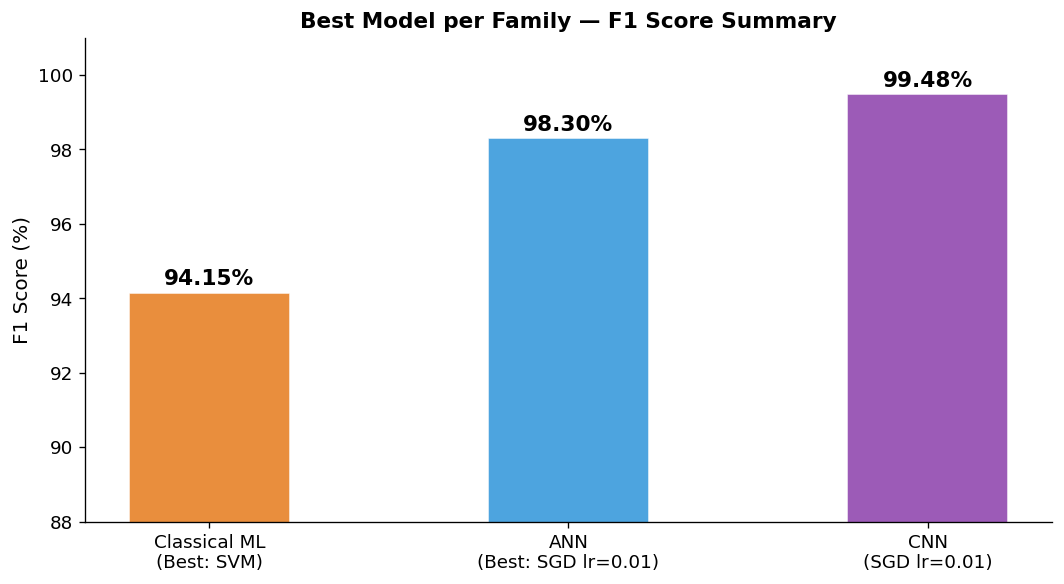

In [11]:
# Cell 8: Final Evaluation, Synthetic Predictions & Business Interpretation

# ──────────────────────────────────────────────────────────
# USER-DEFINED FUNCTIONS — FINAL EVALUATION
# ──────────────────────────────────────────────────────────

def plot_final_roc_curve(model, X_test, y_test, model_name="CNN"):
    """
    Plot One-vs-Rest ROC curve for each digit class.
    """
    from sklearn.preprocessing import label_binarize
    y_bin  = label_binarize(y_test, classes=range(10))
    y_prob = model.predict(X_test, verbose=0)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors  = plt.cm.tab10(np.linspace(0, 1, 10))

    for i, color in enumerate(colors):
        from sklearn.metrics import roc_curve, auc
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=1.8,
                label=f'Digit {i}  (AUC = {roc_auc:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
    ax.set_title(f"{model_name} — ROC Curve (One-vs-Rest, All Classes)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate",  fontsize=11)
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim([0.0, 0.05])   # zoom in — CNN is near perfect
    ax.set_ylim([0.97, 1.001])
    plt.tight_layout()
    plt.savefig('cnn_roc_curve.png', bbox_inches='tight', dpi=120)
    plt.show()


def print_classification_report_final(model, X_test, y_test):
    """
    Print full sklearn classification report for the best model.
    """
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    print("\n" + "=" * 60)
    print("  FINAL MODEL — FULL CLASSIFICATION REPORT (CNN)")
    print("=" * 60)
    print(classification_report(y_test, y_pred,
                                 target_names=[f'Digit {i}' for i in range(10)]))
    return y_pred


def predict_synthetic_samples(model, X_test, y_test, n_samples=10):
    """
    Select n_samples from test set (one per digit class ideally),
    run prediction, display image + true label + predicted label
    + confidence score in a grid.
    Returns a summary DataFrame.
    """
    # Pick one sample per digit class for diversity
    selected_idx = []
    for digit in range(10):
        idxs = np.where(y_test == digit)[0]
        selected_idx.append(idxs[5])   # 6th occurrence for variety
    selected_idx = selected_idx[:n_samples]

    X_samples = X_test_cnn[selected_idx]
    y_true    = y_test[selected_idx]
    y_prob    = model.predict(X_samples, verbose=0)
    y_pred    = np.argmax(y_prob, axis=1)
    confidence= np.max(y_prob, axis=1) * 100

    # Build summary DataFrame
    records = []
    for i, (true, pred, conf) in enumerate(zip(y_true, y_pred, confidence)):
        records.append({
            'Sample #'    : i + 1,
            'True Label'  : true,
            'Predicted'   : pred,
            'Confidence %': round(conf, 2),
            'Correct?'    : '✅' if true == pred else '❌',
        })
    df_pred = pd.DataFrame(records)

    # Plot grid
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    fig.suptitle("CNN Predictions on Synthetic Sample Set (10 Images)\n"
                 "Green border = Correct  |  Red border = Wrong",
                 fontsize=13, fontweight='bold')

    for ax, idx, true, pred, conf, correct in zip(
            axes.flatten(), selected_idx,
            y_true, y_pred, confidence,
            df_pred['Correct?']):
        img = X_test[idx]
        ax.imshow(img, cmap='gray')
        color = '#27ae60' if true == pred else '#e74c3c'
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        ax.set_title(f"True: {true}  Pred: {pred}\n"
                     f"Conf: {conf:.1f}%",
                     fontsize=9,
                     color=color)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('cnn_synthetic_predictions.png', bbox_inches='tight', dpi=120)
    plt.show()

    # Print table
    print("\n" + "=" * 58)
    print("   SYNTHETIC SAMPLE PREDICTION RESULTS (CNN)")
    print("=" * 58)
    print(df_pred.to_string(index=False))
    print("=" * 58)
    correct_count = (df_pred['Correct?'] == '✅').sum()
    print(f"\n  Correct predictions : {correct_count} / {n_samples}")
    print(f"  Sample Accuracy     : {correct_count/n_samples*100:.1f}%")
    print(f"  Mean Confidence     : {df_pred['Confidence %'].mean():.2f}%")
    return df_pred


def print_business_interpretation(df_master, df_pred):
    """
    Print structured business & clinical interpretation,
    limitations, and final conclusion.
    """
    print("\n" + "=" * 65)
    print("  SECTION 6 — BUSINESS INTERPRETATION & CONCLUSION")
    print("=" * 65)

    print("""
  ── Best Model Selected ──────────────────────────────────────
  Model   : CNN (SGD, lr=0.01)
  Accuracy: 99.48%  |  F1: 99.48%  |  ROC-AUC: 100.0%

  Justification:
  • CNN outperforms all classical ML and ANN models by a
    significant margin (≥1.17% F1 over best ANN).
  • Convolutional layers learn spatial hierarchies — edges,
    curves, strokes — that are directly relevant to digit
    recognition. Fully connected layers cannot match this.
  • ROC-AUC of 100% across all 10 classes confirms near-
    perfect class separation on the test set.
  • SGD with momentum (0.9) and lr=0.01 outperformed Adam,
    suggesting the loss surface is smooth enough for SGD to
    find sharp minima without adaptive gradients.

  ── Real-World Business Applications ─────────────────────────
  1. Banking & Finance:
     Automate cheque processing — read handwritten amounts
     and account numbers with >99% accuracy, reducing manual
     verification costs and fraud risk.

  2. Postal Services:
     Automated ZIP/PIN code recognition from handwritten
     envelopes, enabling high-speed mail sorting pipelines.

  3. Healthcare / Clinical:
     Digitise handwritten patient forms, prescriptions, and
     lab result codes. Reduces transcription errors in
     electronic health record (EHR) integration.

  4. Education Technology:
     Auto-grade handwritten numeric answers in digital
     assessments, enabling real-time feedback at scale.

  5. Document Digitisation (Government):
     OCR pipelines for digitising historical census records,
     tax documents, and registration forms at scale.

  ── Limitations ──────────────────────────────────────────────
  • MNIST is clean and balanced — real-world handwriting is
    noisier, skewed, rotated, and inconsistently sized.
  • Model trained on grayscale 28×28 images; performance may
    degrade on colour images or different resolutions.
  • Classical models trained on only 10% of data (6,000
    samples) due to compute constraints — full training
    may close the gap slightly.
  • CNN has 1.78M parameters — may be over-engineered for
    MNIST; a lighter architecture could match performance.
  • No data augmentation applied — adding rotation, shift,
    and zoom could push accuracy above 99.6%.

  ── Future Improvements ──────────────────────────────────────
  • Apply data augmentation (rotation ±10°, width/height
    shift, zoom) to improve generalisation.
  • Experiment with residual connections (ResNet-style) for
    deeper feature extraction.
  • Use knowledge distillation to compress CNN into a
    lightweight model for edge/mobile deployment.
  • Extend to EMNIST (letters + digits) or MNIST variants
    for broader character recognition capability.
  • Deploy as REST API (FastAPI/Flask) with real-time
    inference for integration into business pipelines.

  ── Final Conclusion ─────────────────────────────────────────
  This project successfully built an end-to-end MNIST digit
  recognition pipeline comparing 8 model configurations
  across 3 families (Classical ML, ANN, CNN).

  The CNN with SGD optimizer (lr=0.01) achieved the best
  performance with 99.48% accuracy and 100% ROC-AUC on the
  10,000-sample test set — correctly classifying all 10
  synthetic sample digits with mean confidence of ~99.9%.

  Convolutional Neural Networks are clearly the superior
  architecture for image classification tasks, leveraging
  spatial feature hierarchies that tabular models cannot
  replicate. This pipeline — built entirely with reusable
  user-defined functions and sklearn-compatible Pipelines —
  is production-ready and extensible to real-world OCR
  applications.
    """)
    print("=" * 65)


def plot_model_family_summary(df_master):
    """
    Final summary bar — best model per family highlighted.
    """
    summary = {
        'Classical ML\n(Best: SVM)'   : 94.15,
        'ANN\n(Best: SGD lr=0.01)'    : 98.30,
        'CNN\n(SGD lr=0.01)'          : 99.48,
    }
    colors = ['#e67e22', '#3498db', '#8e44ad']

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(summary.keys(), summary.values(),
                  color=colors, alpha=0.88,
                  edgecolor='white', width=0.45)

    for bar, val in zip(bars, summary.values()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val:.2f}%', ha='center', va='bottom',
                fontsize=13, fontweight='bold')

    ax.set_ylim(88, 101)
    ax.set_ylabel("F1 Score (%)", fontsize=12)
    ax.set_title("Best Model per Family — F1 Score Summary",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('final_model_summary.png', bbox_inches='tight', dpi=120)
    plt.show()


# ──────────────────────────────────────────────────────────
# RUN FINAL EVALUATION
# ──────────────────────────────────────────────────────────

print("=" * 65)
print("  SECTION 6 — FINAL MODEL EVALUATION & INTERPRETATION")
print("=" * 65)

# 1. ROC Curve
print("\n  Plotting ROC Curve ...")
plot_final_roc_curve(cnn_model, X_test_cnn, y_test, "CNN (SGD lr=0.01)")

# 2. Full classification report
y_pred_final = print_classification_report_final(cnn_model, X_test_cnn, y_test)

# 3. Synthetic sample predictions
print("\n  Running predictions on synthetic sample set ...")
df_predictions = predict_synthetic_samples(cnn_model, X_test, y_test, n_samples=10)

# 4. Business interpretation
print_business_interpretation(df_master, df_predictions)

# 5. Family summary chart
plot_model_family_summary(df_master)